# Proteins

**What you'll learn.** The numbered tutorials introduce one idea at a time on a
handful of entities. This notebook is the protein *deep dive*: every distinct
protein language model in embpy, compared with every metric embpy ships, plus
the readouts that only exist for proteins -- residue-level attention,
ortholog conservation, and per-site weighting.

It answers four questions in order:

| Section | Question |
| --- | --- |
| [Embed](#embed-every-protein-model) | which protein models exist, and what do they cost? |
| [Compare](#1-global-geometry) | do they encode the same structure? |
| [Interpret](#does-the-geometry-track-biology) | does that structure track protein biology? |
| [Read inside](#reading-esm-2s-attention) | what is the model actually looking at? |

Prerequisites: [Comparing embeddings](03_compare_embeddings.ipynb) for the
metric definitions and [Reading a model's attention](06_attention_weights.ipynb)
for the extract-then-summarise pattern. Both are used here without re-deriving.

In [1]:
import json
import time
import warnings
from pathlib import Path

import anndata as ad
import numpy as np
import pandas as pd
from IPython.display import display

from embpy import BioEmbedder, pl, tl

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

# Every ESM checkpoint reports "some weights were newly initialised" for its
# pooler head. Mean pooling never touches that head, so the notice is noise here;
# quieting it keeps the tables below readable.
from transformers import logging as hf_logging

hf_logging.set_verbosity_error()

embedder = BioEmbedder(device="auto", organism="human")

## A panel with real structure in it

Comparison metrics need enough entities to be meaningful, and interpretation
needs *labels that are not derived from the embeddings*. So the panel is 40 human
proteins in five functional classes of eight — a grouping from protein biology,
not from any model. Every metric below is scored against it.

The classes are deliberately of mixed difficulty. Some are defined by a shared
fold (kinases, glycolytic enzymes), which a sequence model should find easily.
Others are defined by what the protein *does* rather than how it is built —
"protease" spans unrelated catalytic mechanisms, and "secreted" mixes 99-residue
chemokines with much larger growth factors. Whether that distinction shows up in
the embeddings is measured below rather than assumed.

In [2]:
PANEL: dict[str, list[str]] = {
    "kinase":   ["CDK1", "CDK2", "MAPK1", "MAPK3", "AURKA", "PLK1", "SRC", "CHEK1"],
    "TF":       ["TP53", "JUN", "FOS", "IRF1", "GATA3", "FOXP3", "MYC", "STAT1"],
    "secreted": ["IL2", "IL6", "TNF", "VEGFA", "IGF1", "TGFB1", "IL4", "CXCL8"],
    "glycolysis": ["GAPDH", "LDHA", "PKM", "ALDOA", "ENO1", "PGK1", "TPI1", "GPI"],
    "protease": ["CASP3", "CASP8", "CASP9", "CTSB", "GZMB", "BAX", "BID", "MMP9"],
}

symbols = [s for members in PANEL.values() for s in members]
families = [fam for fam, members in PANEL.items() for _ in members]

protein_space = ad.AnnData(
    X=np.zeros((len(symbols), 1), dtype=np.float32),
    obs=pd.DataFrame(
        {"symbol": symbols, "family": pd.Categorical(families)},
        index=pd.Index(symbols, name="protein"),
    ),
    var=pd.DataFrame(index=["placeholder"]),
)

print(f"{protein_space.n_obs} proteins in {len(PANEL)} classes")
print(protein_space.obs["family"].value_counts().to_string())

40 proteins in 5 classes
family
TF            8
glycolysis    8
kinase        8
protease      8
secreted      8


## Which protein models does embpy have?

`model_catalog` is the inventory. 23 protein keys is misleading, though: most are
*size or seed variants* of the same trained model, and comparing `esm2_650M`
against `esm2_3B` measures scale, not architecture.

In [3]:
catalog = embedder.model_catalog("protein")
display(catalog)

,model,family
0,boltz2,protein
1,boltz2_both,protein
2,boltz2_pairwise,protein
3,esm1b,protein
4,esm1v_1,protein
5,esm1v_2,protein
6,esm1v_3,protein
7,esm1v_4,protein
8,esm1v_5,protein
9,esm2_150M,protein


So the roster below picks **one checkpoint per distinct model**, which is what
makes a cross-model comparison mean anything:

| Key | Model | Why it earns a slot |
| --- | --- | --- |
| `esm1b` | ESM-1b (2020) | the original large PLM; a genuine predecessor, not a smaller ESM-2 |
| `esm1v_1` | ESM-1v | trained for *variant effect*, not general representation — same size as ESM-1b, different objective |
| `esm2_650M` | ESM-2 | the modern default; one size stands in for 8M–15B |
| `esmc_300m` | ESM-C | later EvolutionaryScale line, separate codebase from ESM-2 |
| `prot_t5_xl_half` | ProtT5 | encoder–decoder from ProtTrans — a different lineage entirely |

Skipped on purpose: `esm2_8M/35M/150M/3B/15B` and `esm1v_2..5` (scale and seed
variants — `esm1v` ships as a 5-seed ensemble, and one seed is enough to show
where the space sits); `esm3_*` (needs a licence-gated checkpoint and a Forge
token); `boltz2*` (a structure predictor, and its `boltz` dependency pins
`numpy<2`, so it needs an environment of its own).

`get_model(..., load=False)` reads a wrapper's declared capabilities without
downloading weights — which is how the table below can mention a 15B checkpoint
cheaply.

In [4]:
ROSTER = ["esm1b", "esm1v_1", "esm2_650M", "esmc_300m", "prot_t5_xl_half"]

rows = []
for key in ROSTER + ["esm2_15B", "esm3_small", "boltz2"]:
    try:
        w = embedder.get_model(key, load=False)
        rows.append({"model": key, "wrapper": type(w).__name__,
                     "has_attention": w.has_attention, "status": "available"})
    except Exception as exc:
        rows.append({"model": key, "wrapper": "-", "has_attention": None,
                     "status": f"{type(exc).__name__}"})

display(pd.DataFrame(rows).set_index("model"))

,wrapper,has_attention,status
model,,,
esm1b,ESM2Wrapper,True,available
esm1v_1,ESM2Wrapper,True,available
esm2_650M,ESM2Wrapper,True,available
esmc_300m,ESMCWrapper,False,available
prot_t5_xl_half,ProtT5Wrapper,True,available
esm2_15B,ESM2Wrapper,True,available
esm3_small,ESM3Wrapper,False,available
boltz2,Boltz2Wrapper,True,available


## Resolve first, and measure the sequences

Long proteins are the quiet failure mode of every protein language model, and the
way they fail is worse than it looks. Three things are true of ESM-2 at once:

* `ESM2Wrapper` tokenises with `truncation=True`, but the ESM tokenizer ships **no
  `model_max_length`** — so that flag is a no-op and nothing is trimmed. The
  tokenizer even says so: *"Asking to truncate to max_length but no maximum length
  is provided ... Default to no truncation."*
* The config advertises `max_position_embeddings = 1026`, but ESM-2 uses **rotary**
  position embeddings, which extrapolate rather than index a fixed table.
* So a 2000-residue protein raises **no error**, is **not truncated**, and returns
  a perfectly normal-looking vector — computed well outside the window the model
  was trained on.

No truncation, no exception, no warning about the actual problem. The only way to
know is to measure, so resolve the sequences explicitly and look at them before
trusting anything downstream.

In [5]:
from embpy.resources.protein_resolver import ProteinResolver

resolver = ProteinResolver(organism="human")
sequences = {s: resolver.get_canonical_sequence(s, id_type="symbol") for s in symbols}

missing = [s for s, q in sequences.items() if not q]
if missing:
    print(f"unresolved (UniProt lookup failed): {missing}")

protein_space.obs["length"] = [len(sequences[s]) if sequences[s] else 0 for s in symbols]

lengths = protein_space.obs["length"]
print(f"length: min {lengths.min()}  median {int(lengths.median())}  max {lengths.max()}")
print("\nlongest five:")
print(protein_space.obs.nlargest(5, "length")[["family", "length"]].to_string())

length: min 99  median 371  max 750

longest five:
             family  length
protein                    
STAT1            TF     750
MMP9       protease     707
PLK1         kinase     603
GPI      glycolysis     558
SRC          kinase     536


In [6]:
# ESM-2 was trained on a 1024-token window: 1022 residues plus <cls> and <eos>.
ESM_RESIDUE_LIMIT = 1022

probe_wrapper = embedder.get_model("esm2_650M")
print(f"tokenizer.model_max_length      : {probe_wrapper.tokenizer.model_max_length:.3g}"
      "   <- unset, so truncation=True does nothing")
print(f"config.max_position_embeddings  : {probe_wrapper.model.config.max_position_embeddings}"
      "   <- rotary, so not a hard ceiling")
embedder.clear_model_cache()

over = protein_space.obs.query("length > @ESM_RESIDUE_LIMIT")
if len(over):
    print(f"\n{len(over)} sequence(s) exceed the trained window -- they would be "
          "extrapolated, not truncated, and not flagged:")
    print(over[["family", "length"]].to_string())
else:
    print(f"\nAll {protein_space.n_obs} sequences fit the {ESM_RESIDUE_LIMIT}-residue "
          f"trained window (longest: {lengths.max()}), so nothing below is "
          "confounded by out-of-window extrapolation.")

tokenizer.model_max_length      : 1e+30   <- unset, so truncation=True does nothing
config.max_position_embeddings  : 1026   <- rotary, so not a hard ceiling

All 40 sequences fit the 1022-residue trained window (longest: 750), so nothing below is confounded by out-of-window extrapolation.


## Embed every protein model

One `embed` call per model, each writing its own `.obsm` key. Two practical
points:

* **`clear_model_cache()` between models.** Five checkpoints at once is roughly
  11 GB of weights; embpy caches wrappers by default, which is the right choice
  when you re-embed but the wrong one when you sweep. Dropping each model after
  use keeps the peak at one model.
* **Optional backends degrade, they do not fail.** ESM-C needs the
  EvolutionaryScale SDK (`pip install esm --no-deps`); if it is missing, that row
  is skipped with a reason and everything downstream adapts.

In [7]:
spaces: dict[str, str] = {}
timings = []

for key in ROSTER:
    obsm_key = f"X_{key}"
    t0 = time.perf_counter()
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            protein_space = embedder.embed(
                protein_space, entity_type="protein", id_type="symbol",
                obs_column="symbol", model=key, output="anndata",
                attach_to="obs", key=obsm_key, pooling_strategy="mean",
            )
        elapsed = time.perf_counter() - t0
        spaces[key] = obsm_key
        timings.append({"model": key, "dim": protein_space.obsm[obsm_key].shape[1],
                        "seconds": round(elapsed, 1), "status": "ok"})
    except Exception as exc:
        timings.append({"model": key, "dim": None, "seconds": round(time.perf_counter() - t0, 1),
                        "status": f"skipped -- {type(exc).__name__}: {str(exc)[:60]}"})
    finally:
        embedder.clear_model_cache()

display(pd.DataFrame(timings).set_index("model"))
print("\nembedded spaces:", list(spaces.values()))

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

,dim,seconds,status
model,,,
esm1b,1280,135.9,ok
esm1v_1,1280,73.7,ok
esm2_650M,1280,83.6,ok
esmc_300m,960,40.9,ok
prot_t5_xl_half,1024,145.5,ok



embedded spaces: ['X_esm1b', 'X_esm1v_1', 'X_esm2_650M', 'X_esmc_300m', 'X_prot_t5_xl_half']


In [8]:
# Everything below works off this dict, so a skipped model simply drops out.
embeddings = {key: np.asarray(protein_space.obsm[obsm]) for key, obsm in spaces.items()}
keys = list(embeddings)
obsm_keys = [spaces[k] for k in keys]
print({k: v.shape for k, v in embeddings.items()})

{'esm1b': (40, 1280), 'esm1v_1': (40, 1280), 'esm2_650M': (40, 1280), 'esmc_300m': (40, 960), 'prot_t5_xl_half': (40, 1024)}


## 1. Global geometry

`alignment_matrix` applies one metric to every pair. **TSI** first: it compares
distance *orderings*, so its null is a fixed 0.5 whatever the dimensionality —
and these spaces range from 320 to 1280 dimensions, so a metric that is
comparable across them matters.

In [9]:
tsi_matrix = tl.alignment_matrix(embeddings, metric="tsi")
display(tsi_matrix.round(3))

,esm1b,esm1v_1,esm2_650M,esmc_300m,prot_t5_xl_half
esm1b,1.000,0.799,0.709,0.770,0.759
esm1v_1,0.799,1.000,0.664,0.752,0.757
esm2_650M,0.709,0.664,1.000,0.714,0.691
esmc_300m,0.770,0.752,0.714,1.000,0.786
prot_t5_xl_half,0.759,0.757,0.691,0.786,1.000


One metric is one opinion. Running all four over the same pairs shows where they
disagree, and *that* is the diagnostic — a pair can share global geometry while
disagreeing completely about neighbourhoods.

In [10]:
METRICS = ["tsi", "qsi", "cka", "mutual_knn"]
pairs = [(keys[i], keys[j]) for i in range(len(keys)) for j in range(i + 1, len(keys))]

# One matrix per metric, then read off the upper triangle by name -- indexing
# explicitly keeps each pair exactly once, with no half-empty mirror rows.
matrices = {metric: tl.alignment_matrix(embeddings, metric=metric) for metric in METRICS}
summary = pd.DataFrame(
    [{"pair": f"{a} / {b}", **{m: matrices[m].loc[a, b] for m in METRICS}}
     for a, b in pairs]
).set_index("pair")

display(summary.round(3).sort_values("tsi", ascending=False))

,tsi,qsi,cka,mutual_knn
pair,,,,
esm1b / esm1v_1,0.799,0.772,0.856,0.710
esmc_300m / prot_t5_xl_half,0.786,0.776,0.785,0.650
esm1b / esmc_300m,0.770,0.756,0.791,0.630
esm1b / prot_t5_xl_half,0.759,0.727,0.825,0.668
esm1v_1 / prot_t5_xl_half,0.757,0.685,0.875,0.688
esm1v_1 / esmc_300m,0.752,0.729,0.762,0.568
esm2_650M / esmc_300m,0.714,0.713,0.581,0.532
esm1b / esm2_650M,0.709,0.700,0.646,0.550
esm2_650M / prot_t5_xl_half,0.691,0.695,0.582,0.552


In [11]:
# similarity_correlation asks the question directly: do two spaces rank the same
# pairwise distances the same way?
corr = pd.concat([
    tl.similarity_correlation(embeddings[a], matrix_b=embeddings[b], label_a=f"{a} / {b}")
    for a, b in pairs
])
display(corr.round(3))

,embedding,target,metric,pearson,pearson_pvalue,spearman,spearman_pvalue,n_pairs
0,esm1b / esm1v_1,target,cosine,0.656,0.0,0.662,0.0,780
0,esm1b / esm2_650M,target,cosine,0.430,0.0,0.503,0.0,780
0,esm1b / esmc_300m,target,cosine,0.677,0.0,0.720,0.0,780
0,esm1b / prot_t5_xl_half,target,cosine,0.680,0.0,0.715,0.0,780
0,esm1v_1 / esm2_650M,target,cosine,0.336,0.0,0.401,0.0,780
0,esm1v_1 / esmc_300m,target,cosine,0.645,0.0,0.618,0.0,780
0,esm1v_1 / prot_t5_xl_half,target,cosine,0.417,0.0,0.432,0.0,780
0,esm2_650M / esmc_300m,target,cosine,0.492,0.0,0.519,0.0,780
0,esm2_650M / prot_t5_xl_half,target,cosine,0.473,0.0,0.446,0.0,780
0,esmc_300m / prot_t5_xl_half,target,cosine,0.677,0.0,0.712,0.0,780


## 2. Local neighbourhoods

Global agreement can hide local disagreement. These ask whether each protein
keeps the *same neighbours* — which is what you actually act on when you use an
embedding to find "proteins like this one".

In [12]:
k = 5
chance = k / (protein_space.n_obs - 1)

local = []
for a, b in pairs:
    _, overlap = tl.compute_knn_overlap(protein_space, spaces[a], spaces[b], k=k)
    _, jac = tl.knn_jaccard(embeddings[a], embeddings[b], k=k)
    local.append({"pair": f"{a} / {b}", "knn_overlap": overlap, "jaccard": jac,
                  "mutual_knn": tl.mutual_knn(embeddings[a], embeddings[b], k=k)})

print(f"k = {k}, chance level ~ k/(n-1) = {chance:.3f}\n")
display(pd.DataFrame(local).set_index("pair").round(3).sort_values("knn_overlap", ascending=False))

k = 5, chance level ~ k/(n-1) = 0.128



,knn_overlap,jaccard,mutual_knn
pair,,,
esm1b / prot_t5_xl_half,0.526,0.526,0.640
esm1v_1 / prot_t5_xl_half,0.521,0.521,0.670
esm1b / esm1v_1,0.448,0.448,0.600
esmc_300m / prot_t5_xl_half,0.447,0.447,0.590
esm1b / esmc_300m,0.428,0.428,0.545
esm2_650M / prot_t5_xl_half,0.426,0.426,0.555
esm1v_1 / esmc_300m,0.412,0.412,0.550
esm2_650M / esmc_300m,0.381,0.381,0.495
esm1b / esm2_650M,0.358,0.358,0.460


`compare_embedding_matrices` runs a standard battery over every pair in one
call — the fastest way to a full picture once you know what the columns mean.

In [13]:
display(tl.compare_embedding_matrices(embeddings, k=k).round(3))

,embedding_a,embedding_b,metric,similarity_pearson,similarity_spearman,knn_jaccard
0,esm1b,esm1v_1,cosine,0.656,0.662,0.448
1,esm1b,esm2_650M,cosine,0.430,0.503,0.358
2,esm1b,esmc_300m,cosine,0.677,0.720,0.428
3,esm1b,prot_t5_xl_half,cosine,0.680,0.715,0.526
4,esm1v_1,esm2_650M,cosine,0.336,0.401,0.341
5,esm1v_1,esmc_300m,cosine,0.645,0.618,0.412
6,esm1v_1,prot_t5_xl_half,cosine,0.417,0.432,0.521
7,esm2_650M,esmc_300m,cosine,0.492,0.519,0.381
8,esm2_650M,prot_t5_xl_half,cosine,0.473,0.446,0.426
9,esmc_300m,prot_t5_xl_half,cosine,0.677,0.712,0.447


The concrete version of the same question: for one protein, who are its
neighbours in each space? `nearest_neighbors_table` is the readout you would
actually use in analysis.

In [14]:
probe = "CDK1"
neighbours = pd.concat([
    tl.nearest_neighbors_table(embeddings[key], ids=list(protein_space.obs_names),
                               query=probe, k=5)
      .assign(model=key)
    for key in keys
])
display(neighbours.set_index(["model", neighbours.index]).round(3))

print(f"\n{probe} is a kinase; its true class-mates are:")
print(" ", ", ".join(PANEL["kinase"]))

query_id neighbor_id  rank  distance  similarity
model                                                             
esm1b           0     CDK1        CDK2     1     0.003       0.997
                1     CDK1       MAPK3     2     0.020       0.980
                2     CDK1         SRC     3     0.023       0.977
                3     CDK1       AURKA     4     0.027       0.973
                4     CDK1        TPI1     5     0.031       0.969
esm1v_1         0     CDK1        CDK2     1     0.002       0.998
                1     CDK1       MAPK3     2     0.012       0.988
                2     CDK1       MAPK1     3     0.018       0.982
                3     CDK1       CHEK1     4     0.026       0.974
                4     CDK1        PLK1     5     0.026       0.974
esm2_650M       0     CDK1        CDK2     1     0.009       0.991
                1     CDK1       MAPK1     2     0.034       0.966
                2     CDK1       MAPK3     3     0.040       0.960
                3     CDK1         SRC     4     0.058       0.942
                4     CDK1         PKM     5     0.061       0.939
esmc_300m       0     CDK1        CDK2     1     0.029       0.971
                1     CDK1       MAPK1     2     0.097       0.903
                2     CDK1       MAPK3     3     0.132       0.868
                3     CDK1         SRC     4     0.155       0.845
                4     CDK1         PKM     5     0.158       0.842
prot_t5_xl_half 0     CDK1        CDK2     1     0.030       0.970
                1     CDK1       MAPK1     2     0.099       0.901
                2     CDK1       MAPK3     3     0.119       0.881
                3     CDK1         SRC     4     0.274       0.726
                4     CDK1        PLK1     5     0.278       0.722


CDK1 is a kinase; its true class-mates are:
  CDK1, CDK2, MAPK1, MAPK3, AURKA, PLK1, SRC, CHEK1


## 3. Visual comparison

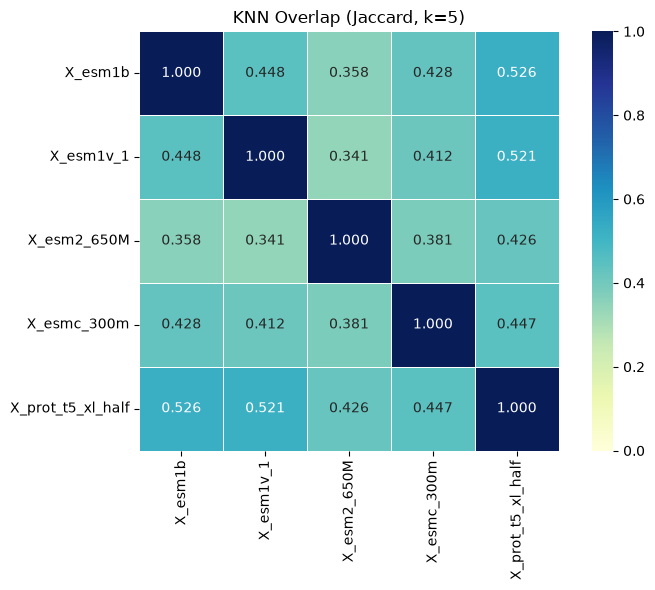

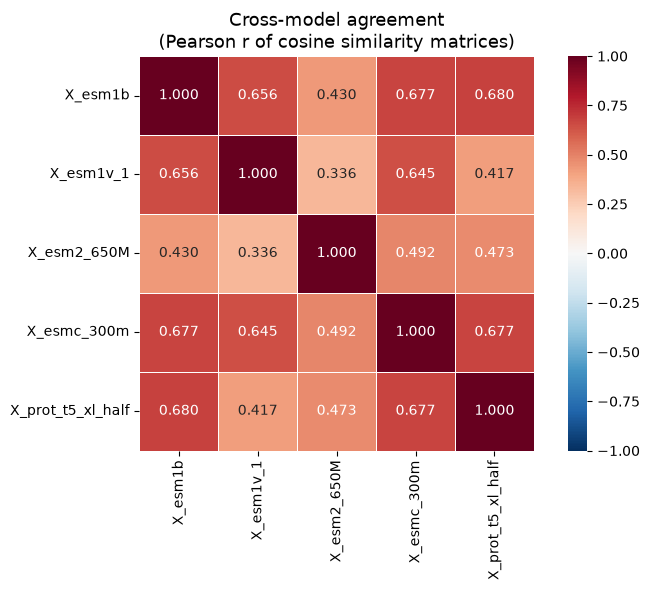

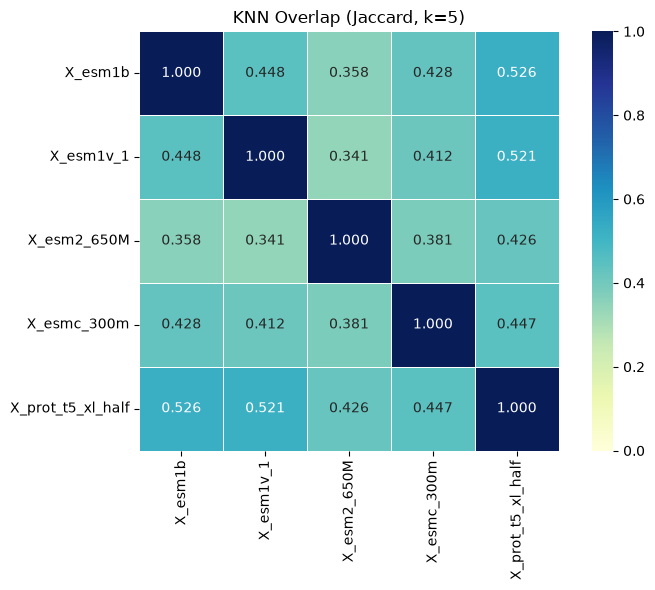

In [15]:
pl.cross_model_similarity(protein_space, obsm_keys=obsm_keys)
pl.knn_overlap(protein_space, obsm_keys=obsm_keys, k=k)

Scale is worth seeing before you ever concatenate, average, or feed these to a
distance-based method: mean-pooled PLM embeddings sit at very different
magnitudes.

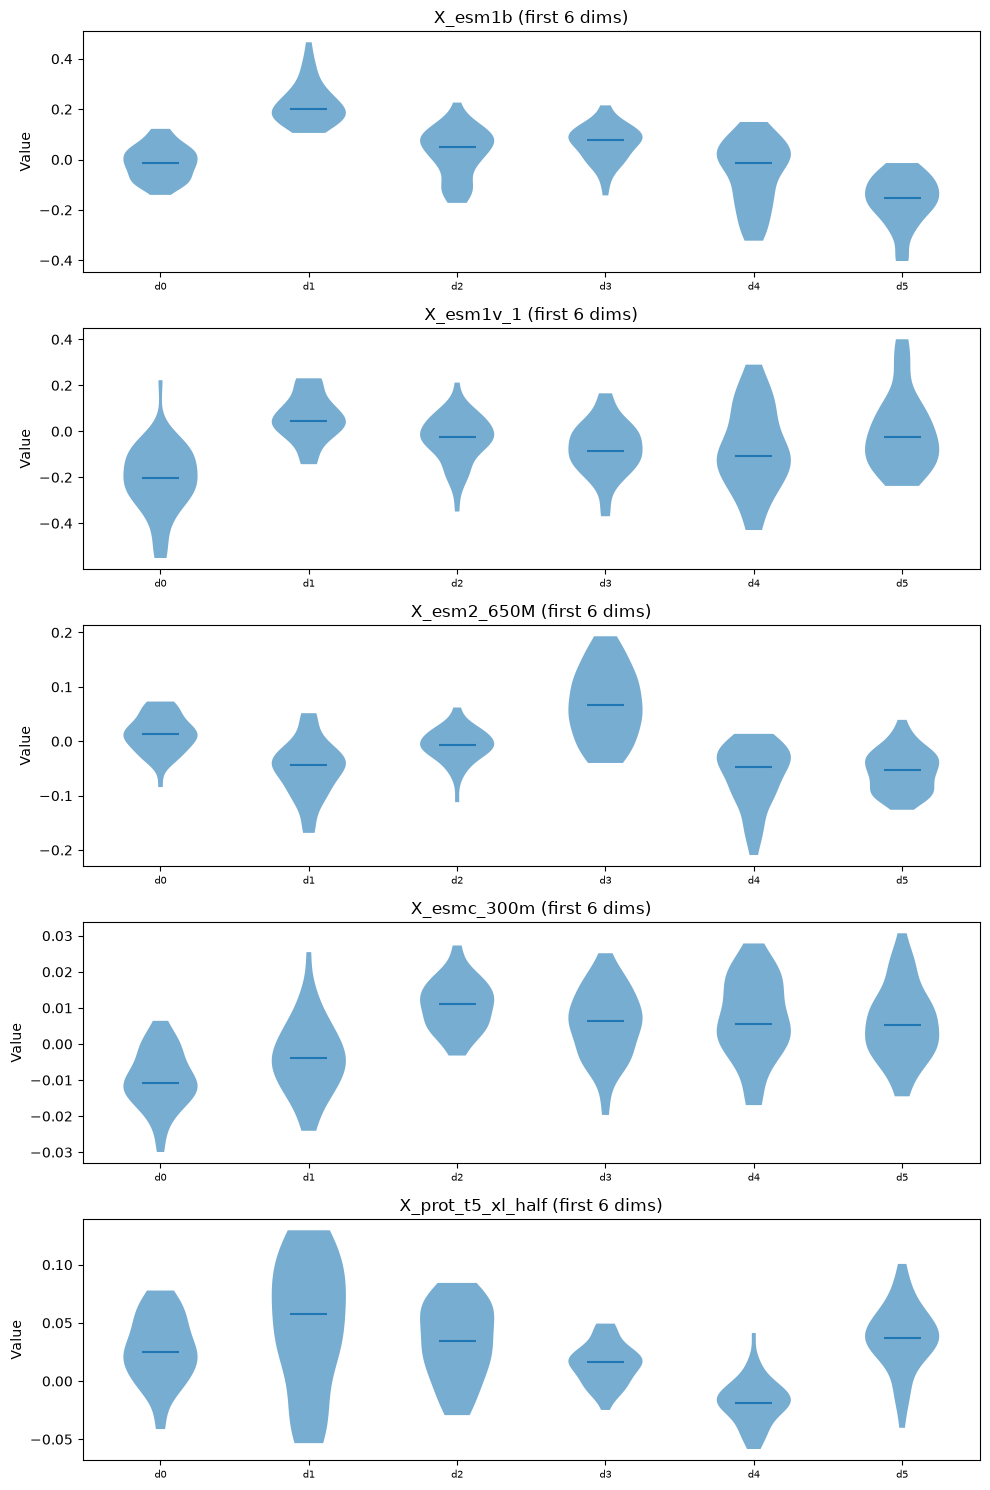

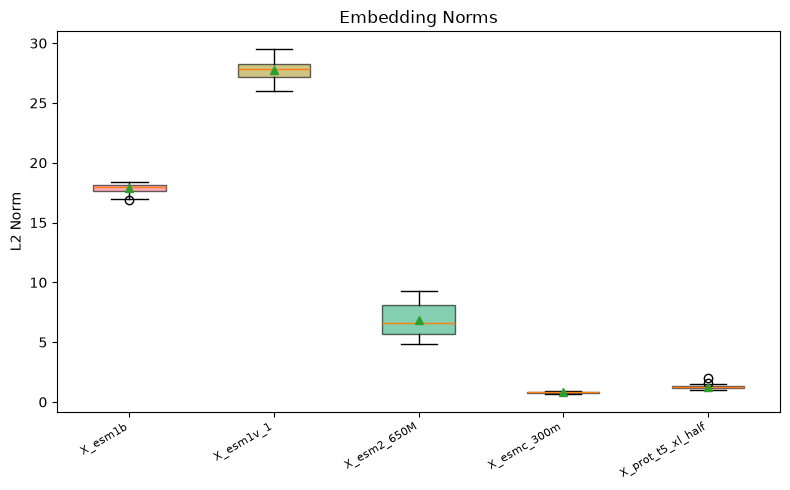

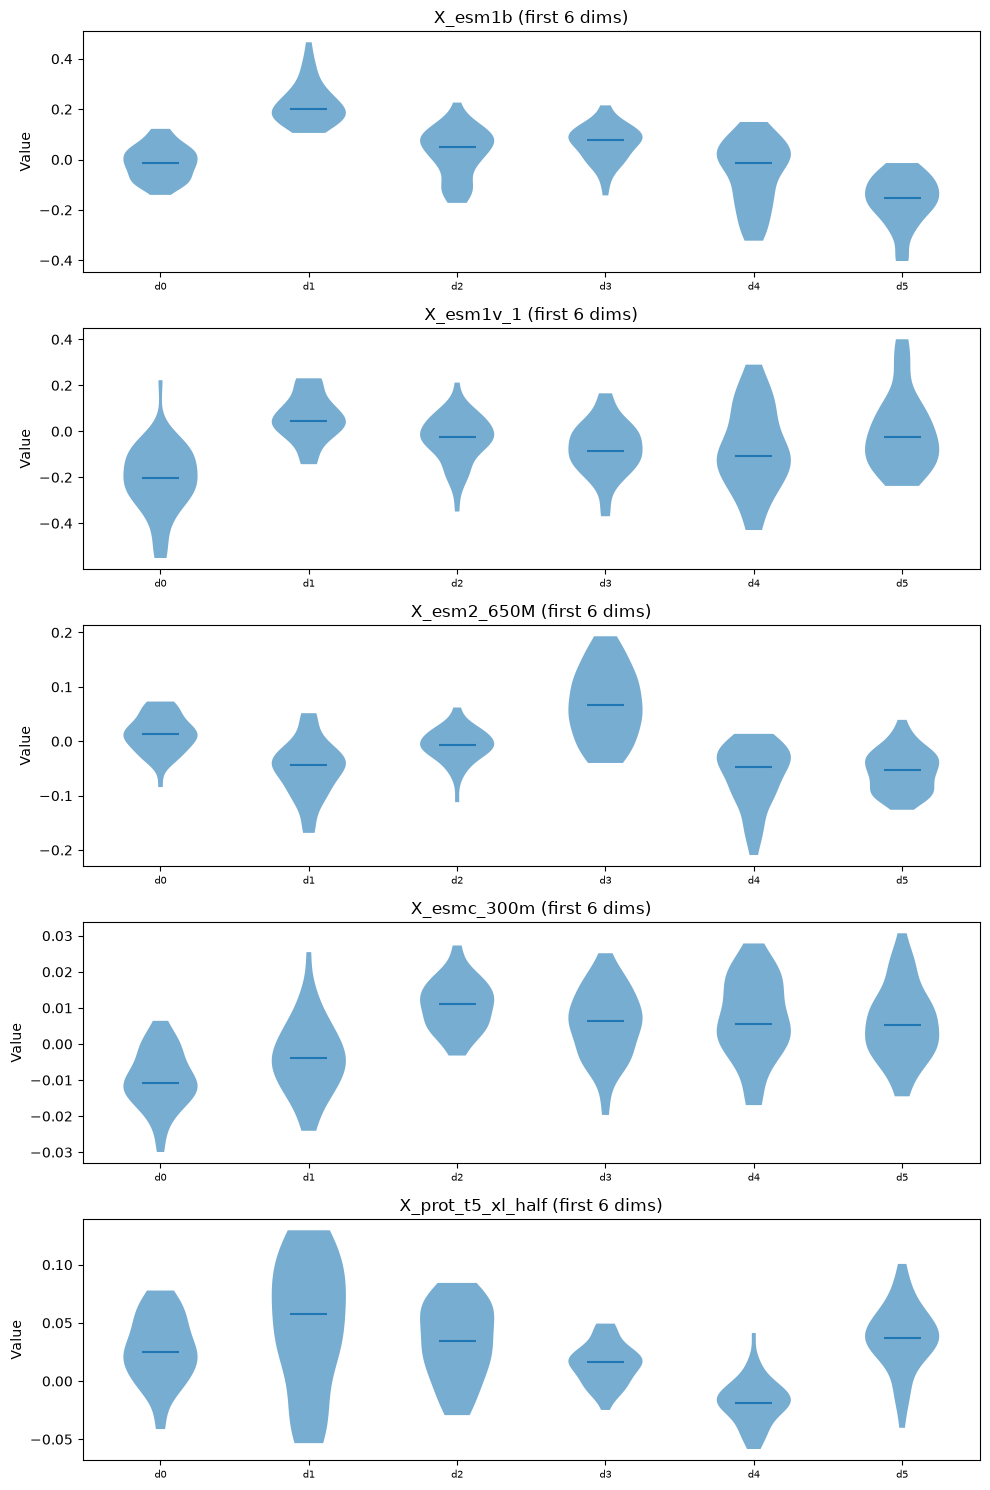

In [16]:
pl.embedding_norms(protein_space, obsm_keys=obsm_keys)
pl.embedding_distributions(protein_space, obsm_keys=obsm_keys, n_dims=6)

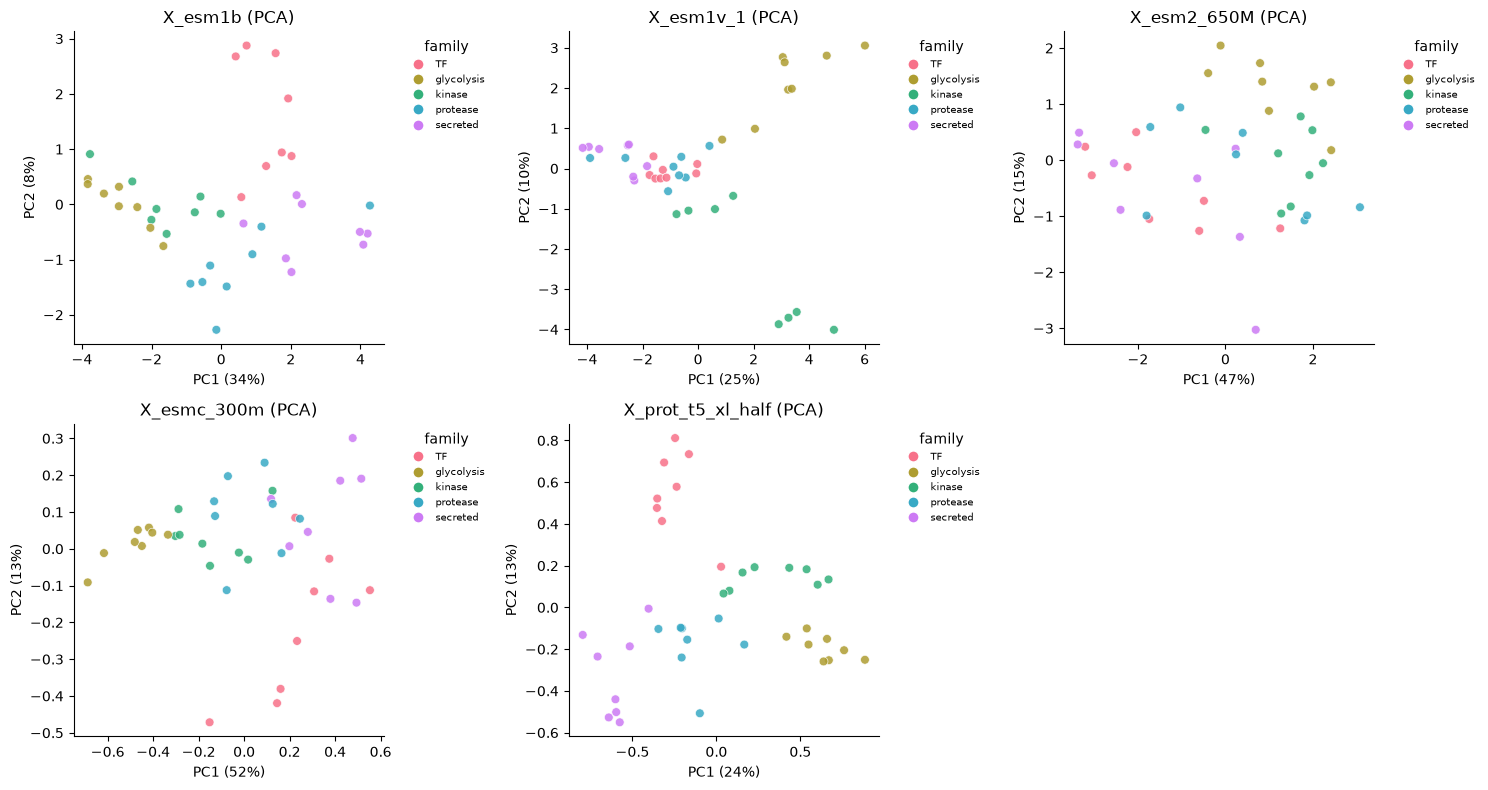

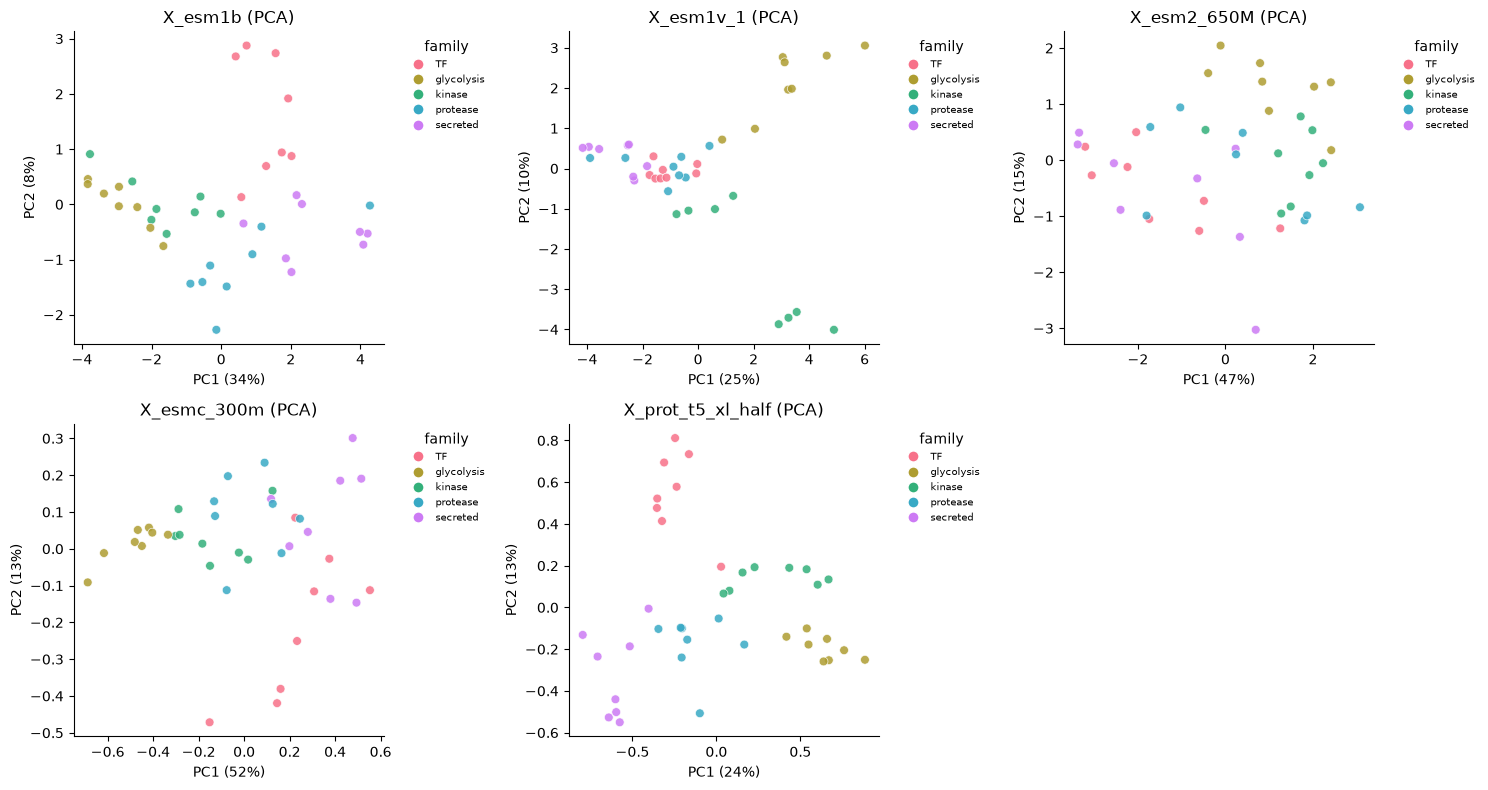

In [17]:
# Same proteins, same colouring, one panel per model -- the qualitative
# counterpart to the tables above.
pl.all_embeddings(protein_space, obsm_keys=obsm_keys, method="pca",
                  color="family", ncols=3)

## Does the geometry track biology?

Everything so far compared models *to each other*. None of it says whether any
of them is right. The `family` labels were never shown to any model, so they are
a fair external test — and this is the section that actually picks a model.

Two complementary readouts:

* `within_vs_between_similarity` — are same-class pairs more similar than
  cross-class pairs? Returns the two means, the counts, and a **p-value**.
* `knn_label_purity` — of each protein's `k` neighbours, how many share its
  class? Reports `__baseline__` (the class-prior floor) alongside, so the number
  is interpretable rather than merely large.

,within,between,separation,p_value,knn_purity,purity_baseline
model,,,,,,
prot_t5_xl_half,0.6433,0.3976,0.2457,0.0,0.780,0.2
esmc_300m,0.8335,0.6478,0.1857,0.0,0.630,0.2
esm2_650M,0.9138,0.8683,0.0456,0.0,0.635,0.2
esm1b,0.9685,0.9474,0.0211,0.0,0.670,0.2
esm1v_1,0.9751,0.9625,0.0126,0.0,0.645,0.2



best class separation: prot_t5_xl_half


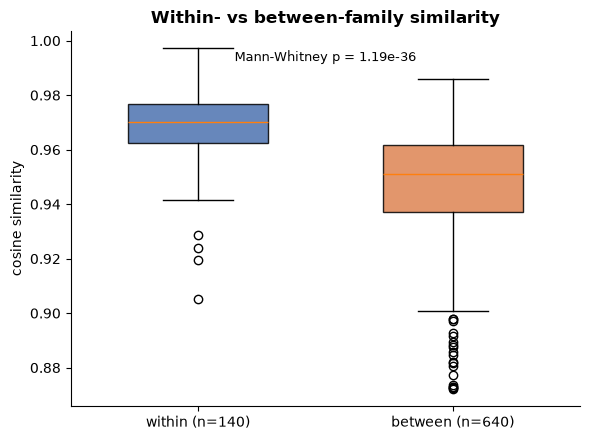

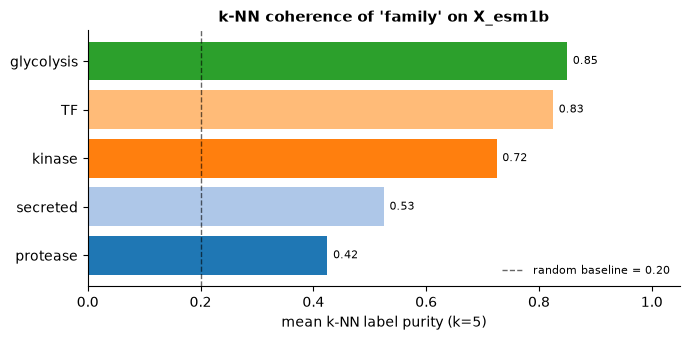

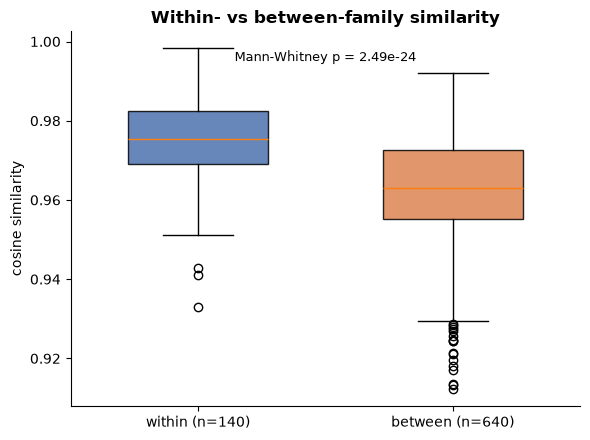

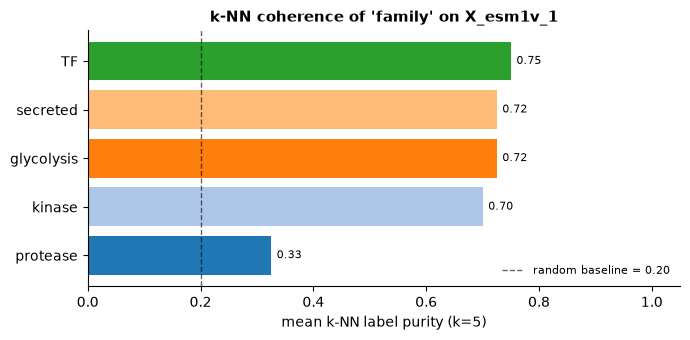

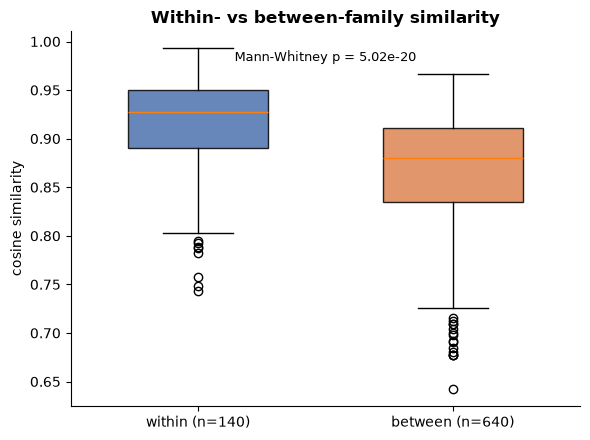

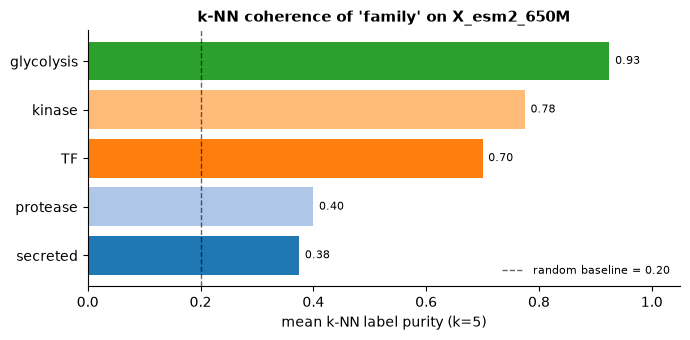

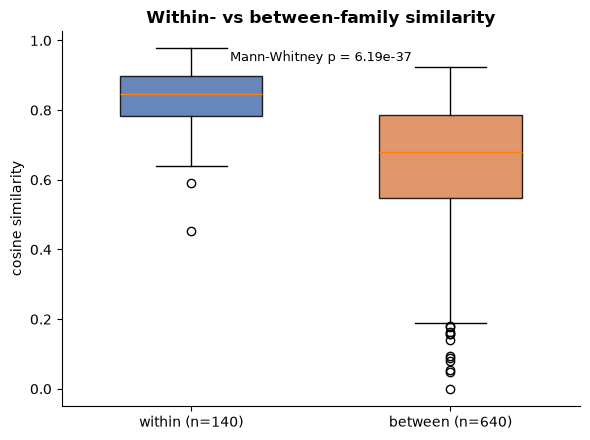

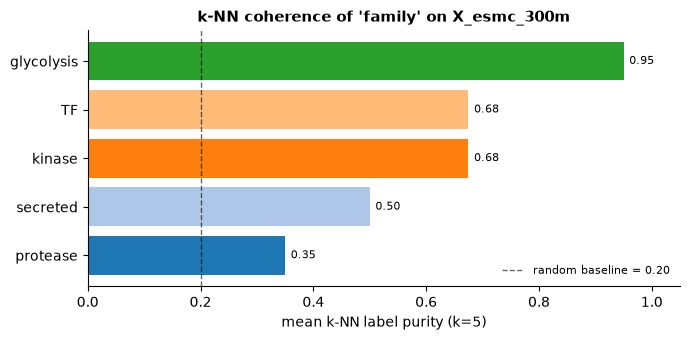

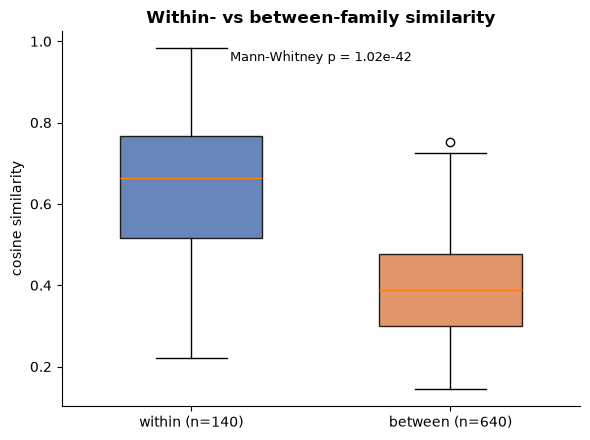

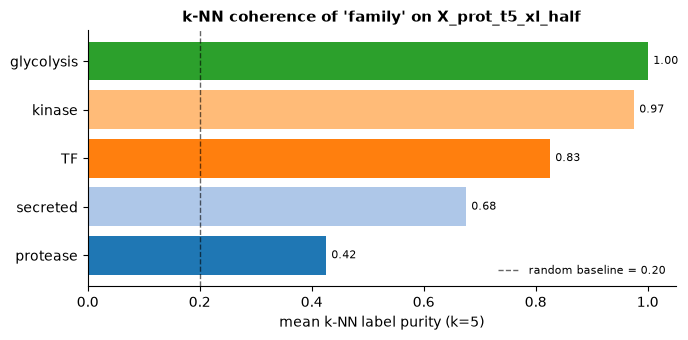

In [18]:
scores = []
for key in keys:
    wb = pl.within_vs_between_similarity(protein_space, label_key="family",
                                         obsm_key=spaces[key])
    purity = pl.knn_label_purity(protein_space, label_key="family",
                                 obsm_key=spaces[key], k=k)
    scores.append({
        "model": key,
        "within": wb["mean_within"],
        "between": wb["mean_between"],
        "separation": wb["mean_within"] - wb["mean_between"],
        "p_value": wb["p_value"],
        "knn_purity": purity["__overall__"],
        "purity_baseline": purity["__baseline__"],
    })

ranking = pd.DataFrame(scores).set_index("model").sort_values("separation", ascending=False)
display(ranking.round(4))

best = ranking.index[0]
print(f"\nbest class separation: {best}")

Read `separation` and `knn_purity` together. Separation is a global statement
(are the classes pulled apart on average) while purity is local (is *this*
protein among its own kind). A model can win one and lose the other, and which
you care about depends on whether you will use the space for grouping or for
lookup.

Per-class purity shows *where* the geometry works. The prediction from the panel
design was that kinases are easy and secreted signalling is hard:

,esm1b,esm1v_1,esm2_650M,esmc_300m,prot_t5_xl_half
protease,0.425,0.325,0.400,0.350,0.425
secreted,0.525,0.725,0.375,0.500,0.675
TF,0.825,0.750,0.700,0.675,0.825
kinase,0.725,0.700,0.775,0.675,0.975
glycolysis,0.850,0.725,0.925,0.950,1.000



baseline for every row: 0.20

easiest class across models : glycolysis (mean purity 0.89)
hardest class across models : protease (mean purity 0.39)


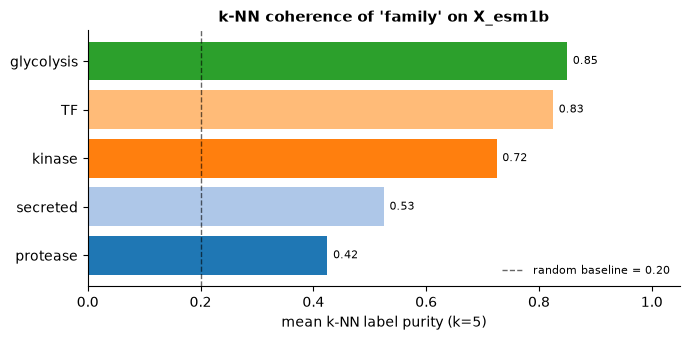

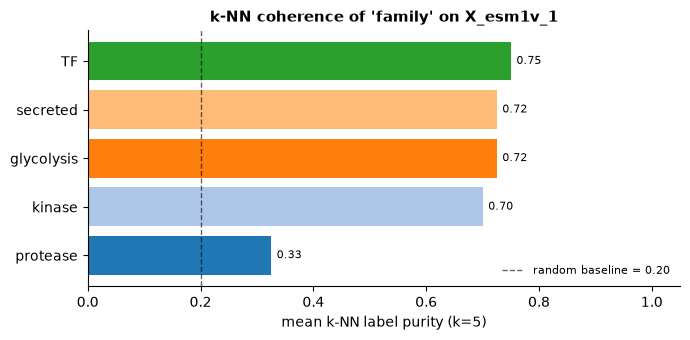

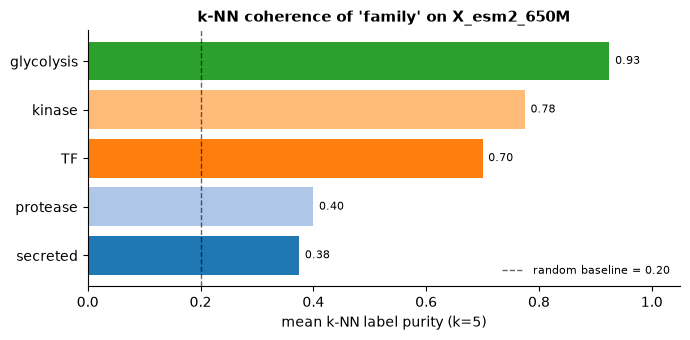

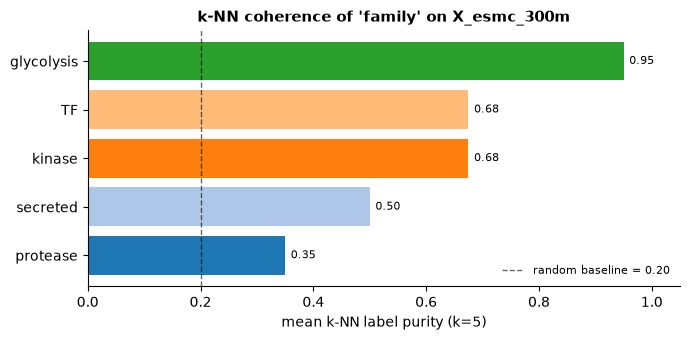

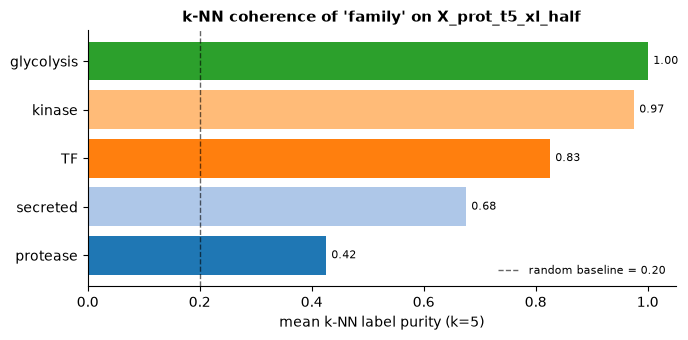

In [19]:
per_class = pd.DataFrame({
    key: pl.knn_label_purity(protein_space, label_key="family",
                             obsm_key=spaces[key], k=k)
    for key in keys
})
per_class = per_class.drop(index=[i for i in ("__baseline__", "__overall__") if i in per_class.index])
per_class = per_class.loc[per_class.mean(axis=1).sort_values().index]
display(per_class.round(3))

print(f"\nbaseline for every row: {1 / len(PANEL):.2f}\n")
easiest, hardest = per_class.index[-1], per_class.index[0]
print(f"easiest class across models : {easiest} "
      f"(mean purity {per_class.loc[easiest].mean():.2f})")
print(f"hardest class across models : {hardest} "
      f"(mean purity {per_class.loc[hardest].mean():.2f})")

The ordering is the interesting part, and it follows structure rather than
function. The classes held together by a **shared fold** — glycolytic enzymes,
kinases — are recovered well by every model. The class defined purely by *what the
protein does* is recovered worst: "protease" groups together catalytic machinery
that is genuinely unrelated in sequence (cysteine proteases, matrix
metalloproteinases, and the pro-apoptotic BCL-2 members BAX and BID, which are not
proteases at all but sit in the same pathway).

That is the honest reading of a protein language model: it encodes sequence and
therefore fold, and it recovers functional categories only to the extent that they
happen to be structural ones. If your labels are pathway or mechanism labels
rather than fold labels, expect exactly this.

,kinase,TF,secreted,glycolysis,protease
kinase,1.000000,0.620993,0.434200,0.742489,0.665228
TF,0.620993,1.000000,0.555990,0.451887,0.611084
secreted,0.434200,0.555990,1.000000,0.346348,0.714640
glycolysis,0.742489,0.451887,0.346348,1.000000,0.625920
protease,0.665228,0.611084,0.714640,0.625920,1.000000


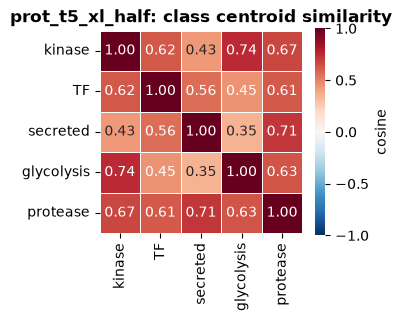

In [20]:
# Which classes does the winning model confuse? Centroid similarity says so
# directly -- off-diagonal heat is a pair the model cannot tell apart.
pl.category_centroid_similarity(protein_space, label_key="family",
                                obsm_key=spaces[best],
                                title=f"{best}: class centroid similarity")

## Unsupervised structure

Clustering asks the same question without the labels: left to itself, does the
embedding rediscover the functional classes? `cluster_annotation_enrichment`
then scores each cluster against the known labels.

In [21]:
protein_space = tl.cluster_embeddings(protein_space, obsm_key=spaces[best],
                                      method="leiden", resolution=1.0,
                                      n_neighbors=8, key_added="cluster")
print(protein_space.obs["cluster"].value_counts().sort_index().to_string())

enrichment = tl.cluster_annotation_enrichment(protein_space, cluster_key="cluster",
                                              annotation_key="family", top_k=3)
display(enrichment)

/ictstr01/groups/ml01/workspace/goncalo.pinto/embpy/src/embpy/tl/clustering.py:128: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=resolution, key_added=key_added)


cluster
0    10
1     9
2     8
3     7
4     6


,cluster,term,in_cluster,overall,in_freq,overall_freq,enrichment
0,0,secreted,8,8,0.800,0.2,4.00
1,0,protease,2,8,0.200,0.2,1.00
2,1,kinase,8,8,0.889,0.2,4.44
3,1,TF,1,8,0.111,0.2,0.56
4,2,glycolysis,8,8,1.000,0.2,5.00
5,3,TF,7,8,1.000,0.2,5.00
6,4,protease,6,8,1.000,0.2,5.00


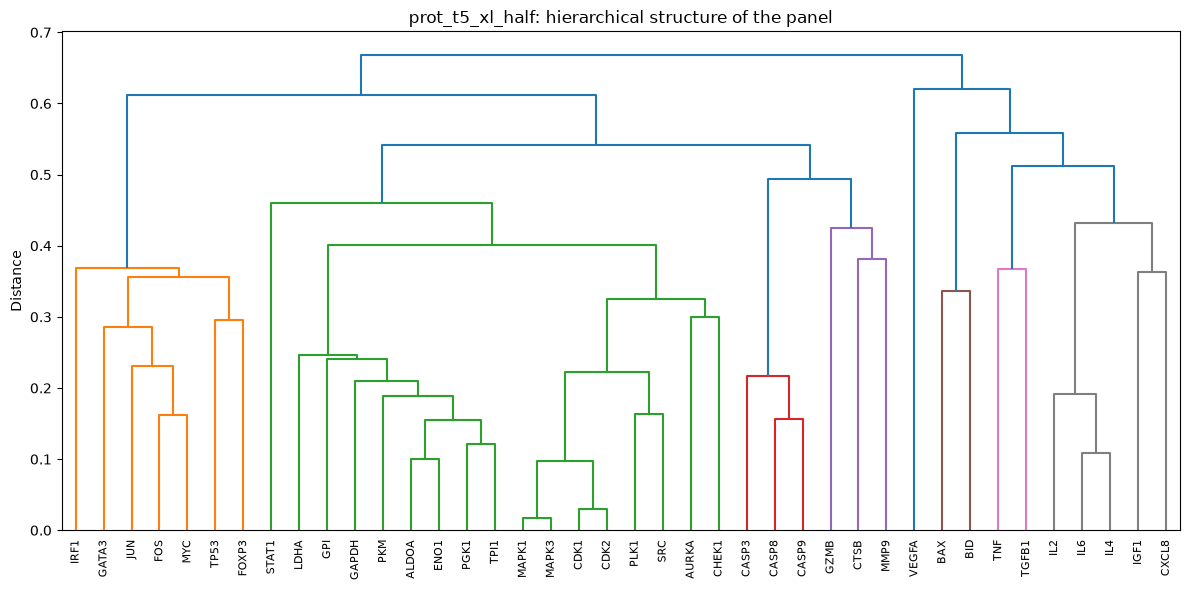

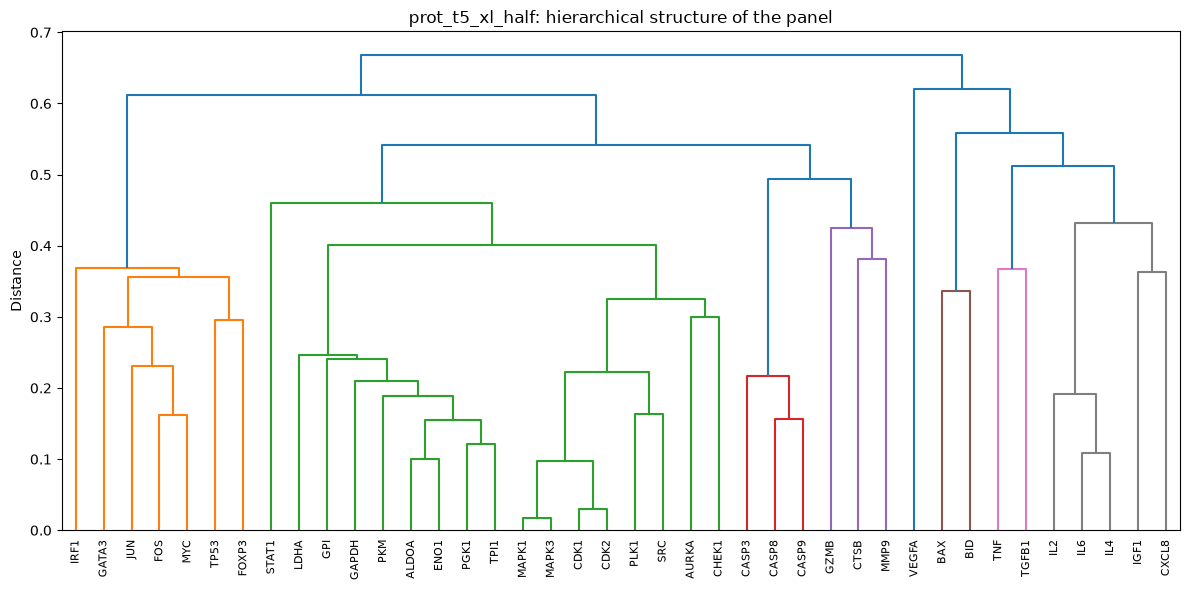

In [22]:
pl.dendrogram(protein_space, obsm_key=spaces[best], metric="cosine",
              title=f"{best}: hierarchical structure of the panel")

## Annotate the proteins

`tl.annotate_proteins` fetches UniProt and InterPro records: subcellular
location, domains, PTMs, disease links, GO terms, interaction counts, isoforms.
Compact summaries land in `.obs` as `prot_*`, full records in
`.uns["protein_annotations"]`.

This is real measured metadata, which makes it usable both for colouring plots
and — in the next section — as a *prediction target*.

In [23]:
protein_space = tl.annotate_proteins(
    protein_space, column="symbol", id_type="symbol",
    sources=["metadata", "function", "location", "domains", "ptms",
             "diseases", "go", "interactions", "isoforms"],
    copy=True,
)

prot_cols = [c for c in protein_space.obs.columns if c.startswith("prot_")]
display(protein_space.obs[["family", *prot_cols]].head(10))
print("annotation records in .uns:", len(protein_space.uns["protein_annotations"]))

,family,prot_reviewed,prot_name,prot_n_domains,prot_n_ptms,prot_n_diseases,prot_n_interactions,prot_n_isoforms,prot_location
protein,,,,,,,,,
CDK1,kinase,True,Cyclin-dependent kinase 1,1,19,0,25,2,Nucleus
CDK2,kinase,True,Cyclin-dependent kinase 2,1,6,0,35,2,"Cytoplasm, cytoskeleton, microtubule organizin..."
MAPK1,kinase,True,Mitogen-activated protein kinase 1,1,8,1,49,2,"Cytoplasm, cytoskeleton, spindle"
MAPK3,kinase,True,Mitogen-activated protein kinase 3,1,5,0,29,3,Cytoplasm
AURKA,kinase,True,Aurora kinase A,1,6,0,23,0,"Cytoplasm, cytoskeleton, microtubule organizin..."
PLK1,kinase,True,Serine/threonine-protein kinase PLK1,3,14,1,46,0,Nucleus
SRC,kinase,True,Proto-oncogene tyrosine-protein kinase Src,3,7,2,97,3,Cell membrane
CHEK1,kinase,True,Serine/threonine-protein kinase Chk1,1,11,1,18,3,Nucleus
TP53,TF,True,Cellular tumor antigen p53,0,36,9,191,9,Cytoplasm


annotation records in .uns: 40


In [24]:
numeric_annotations = [c for c in prot_cols
                       if pd.api.types.is_numeric_dtype(protein_space.obs[c])]
display(protein_space.obs.groupby("family", observed=True)[numeric_annotations].mean().round(1))

,prot_reviewed,prot_n_domains,prot_n_ptms,prot_n_diseases,prot_n_interactions,prot_n_isoforms
family,,,,,,
TF,1.0,0.6,15.8,2.2,60.8,2.9
glycolysis,1.0,0.0,26.5,0.6,14.4,2.6
kinase,1.0,1.5,9.5,0.6,40.2,1.9
protease,1.0,0.9,5.9,0.5,18.8,3.1
secreted,1.0,0.1,4.8,1.2,18.9,2.9


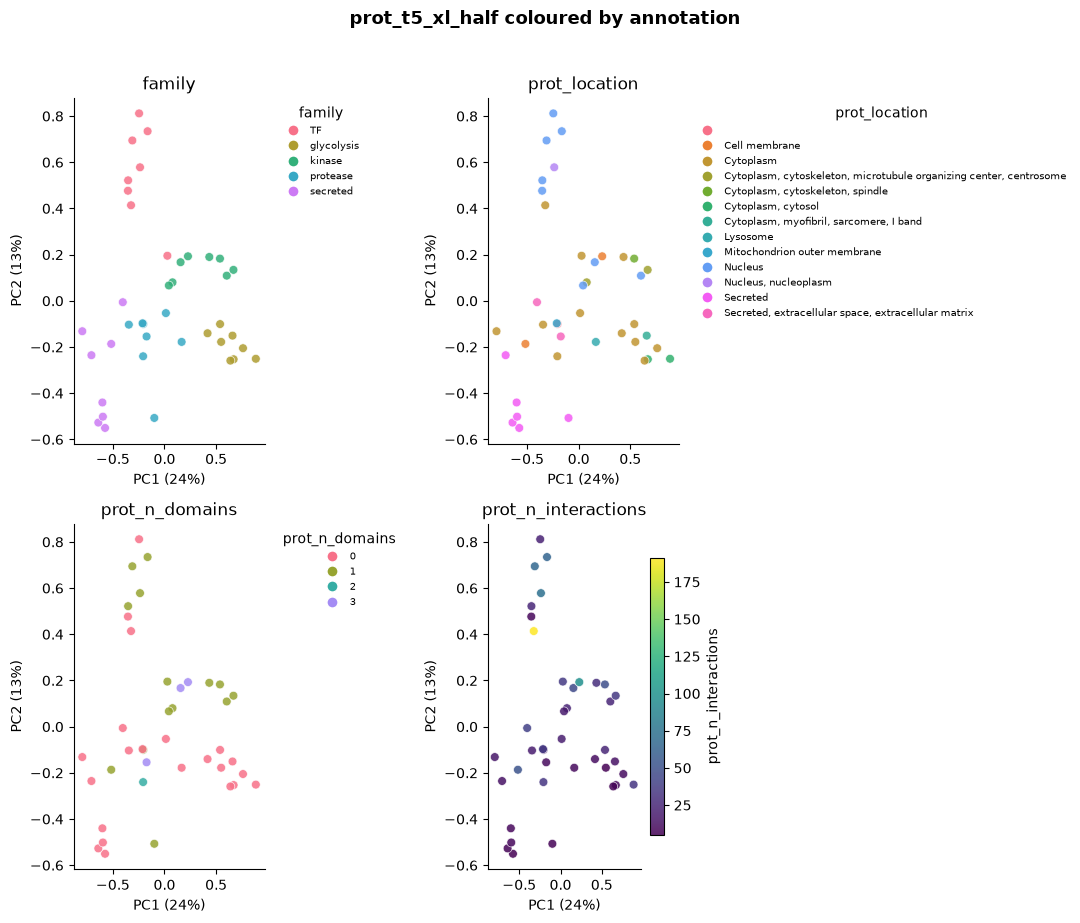

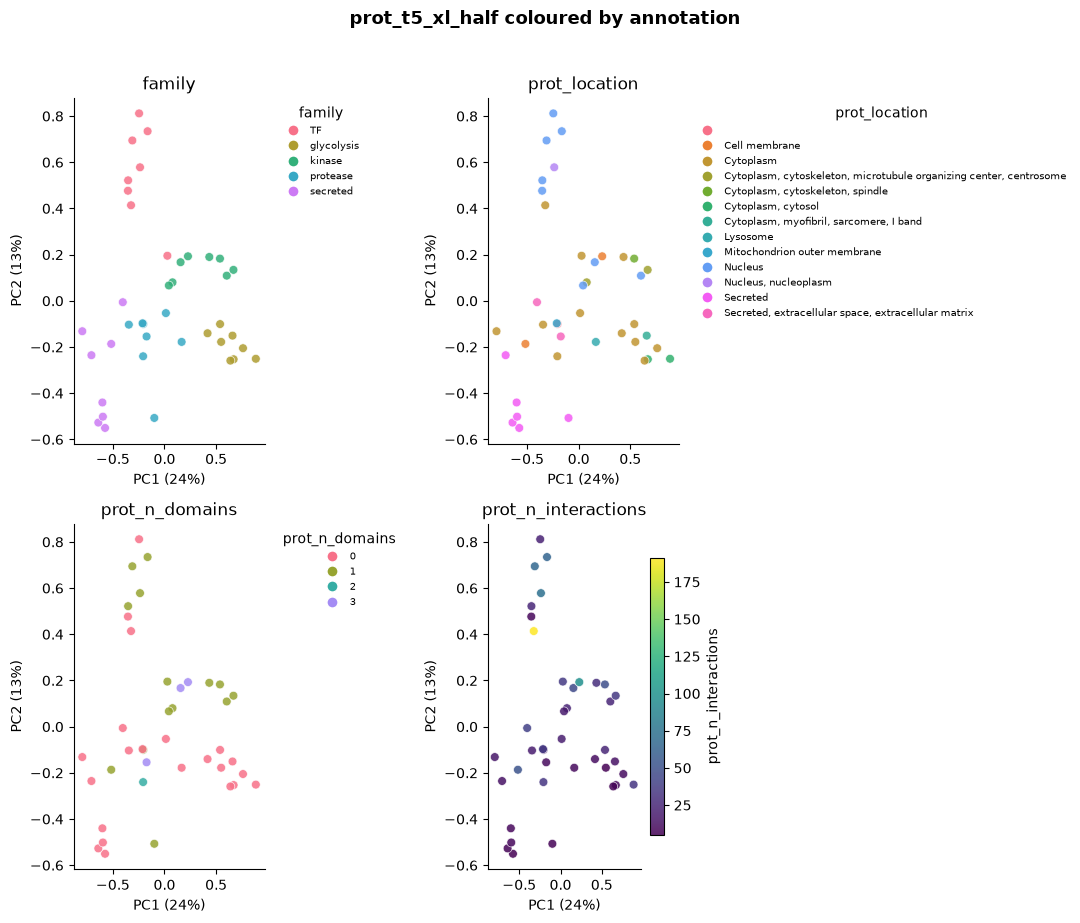

In [25]:
# The same embedding, coloured by several annotation fields at once.
panel_keys = [c for c in ["family", "prot_location", "prot_n_domains", "prot_n_interactions"]
              if c in protein_space.obs]
pl.embedding_color_panel(protein_space, color_keys=panel_keys,
                         obsm_key=spaces[best], method="pca", ncols=2,
                         annotate=False, title=f"{best} coloured by annotation")

## Which layer should you take?

Conventional wisdom says the last layer is specialised toward the pretraining
objective and so is often *not* the best for transfer. That is a claim to test per
task rather than assume — and on this panel it turns out **not** to hold, which is
exactly why the sweep is worth running. `rank_layers` scores every layer against
the final one and against its predecessor, so you can see where the representation
stabilises.

This sweep needs one full forward pass per layer, so it uses **`esm2_8M`** — the
smallest ESM-2. The question is where information sits *with depth*, and the
depth profile is what generalises, not the checkpoint size.

In [26]:
SWEEP_MODEL, SWEEP_BLOCKS = "esm2_8M", 6   # embedding layer + 6 transformer blocks

layer_spaces = {}
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for layer in range(SWEEP_BLOCKS + 1):
        out = embedder.embed(
            protein_space.copy(), entity_type="protein", id_type="symbol",
            obs_column="symbol", model=SWEEP_MODEL, layer=layer,
            output="anndata", attach_to="obs", key="X_layer",
        )
        layer_spaces[layer] = np.asarray(out.obsm["X_layer"])
embedder.clear_model_cache()

display(tl.rank_layers(layer_spaces).round(3))

,to_final,to_previous
layer,,
0,0.617,NaN
1,0.631,0.838
2,0.641,0.879
3,0.763,0.741
4,0.817,0.839
5,0.824,0.873
6,1.000,0.824


,separation,p_value
layer,,
0,0.0222,0.0
1,0.0119,0.0
2,0.0247,0.0
3,0.0218,0.0
4,0.0191,0.0
5,0.0338,0.0
6,0.0774,0.0



best-separating layer: 6 of 6 (final = 6)
The final layer wins here, so the usual 'prefer an intermediate layer' advice does not apply to this panel -- which is why it is worth checking.


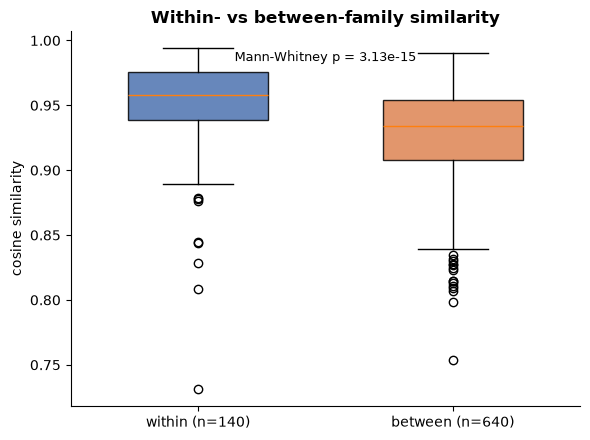

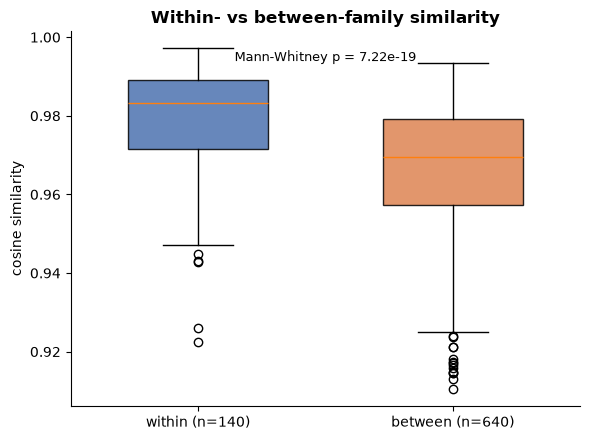

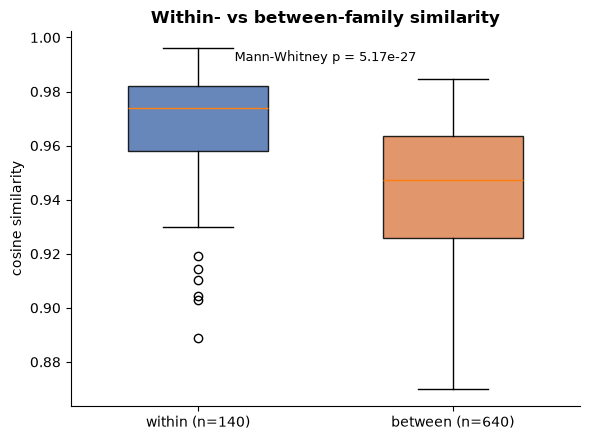

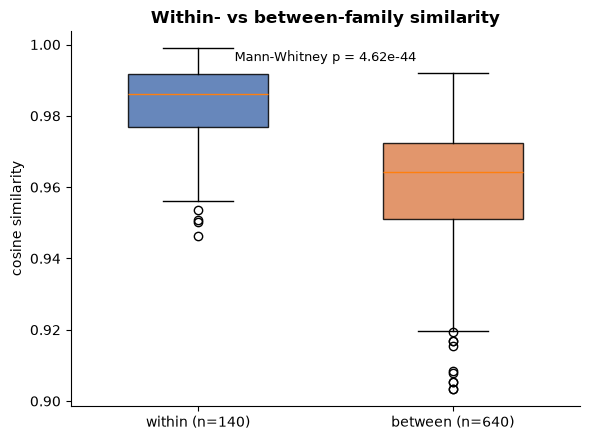

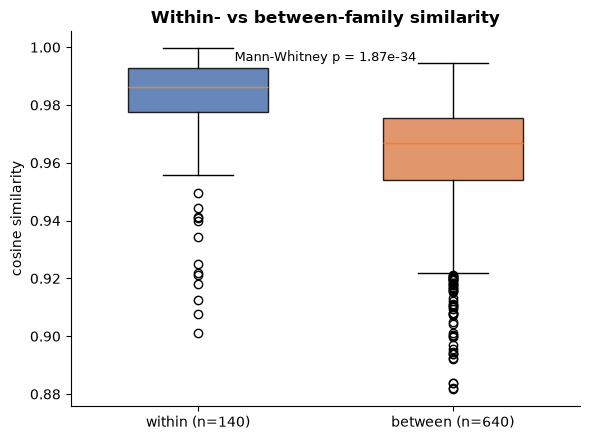

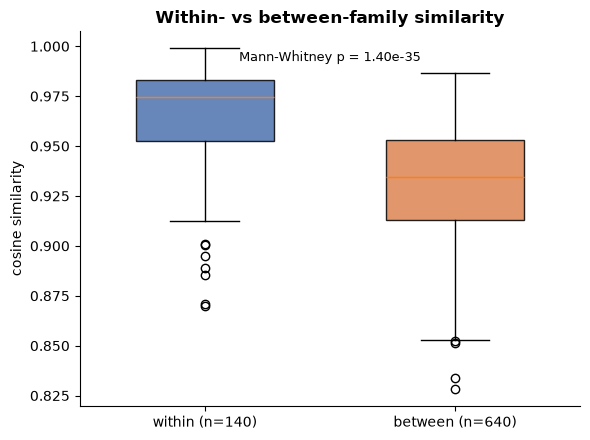

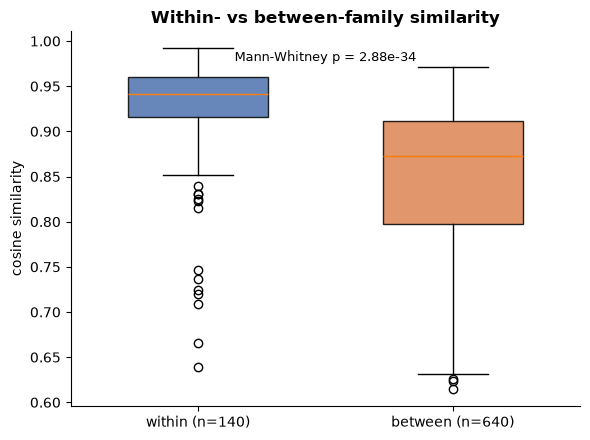

In [27]:
# Does the class signal itself peak before the last layer? Score every layer the
# same way the models were scored above.
layer_scores = []
for layer, matrix in layer_spaces.items():
    probe_space = protein_space.copy()
    probe_space.obsm["X_probe"] = matrix
    wb = pl.within_vs_between_similarity(probe_space, label_key="family", obsm_key="X_probe")
    layer_scores.append({"layer": layer,
                         "separation": wb["mean_within"] - wb["mean_between"],
                         "p_value": wb["p_value"]})

layer_table = pd.DataFrame(layer_scores).set_index("layer")
display(layer_table.round(4))
best_layer = layer_table["separation"].idxmax()
print(f"\nbest-separating layer: {best_layer} of {SWEEP_BLOCKS} (final = {SWEEP_BLOCKS})")
if best_layer == SWEEP_BLOCKS:
    print("The final layer wins here, so the usual 'prefer an intermediate layer' "
          "advice does not apply to this panel -- which is why it is worth checking.")
else:
    gain = layer_table.loc[best_layer, "separation"] - layer_table.loc[SWEEP_BLOCKS, "separation"]
    print(f"An intermediate layer beats the final one by {gain:.4f} separation.")

## Reading ESM-2's attention

A pooled vector is one number per dimension for a whole protein. Attention is
per-residue, and for proteins that is unusually interpretable: the tokens *are*
amino acids at known positions, so "what does the model read" can be checked
against annotated domains.

`get_model()` hands back the wrapper; the wrapper exposes the internals.

> **Structural, not causal.** Attention says what attends to what. Jain & Wallace
> (NAACL 2019, *Attention is not Explanation*) showed attention can be altered
> substantially without changing predictions, so a high-attention residue is not
> thereby shown to have driven the embedding. For "what drove this vector",
> gradient attribution on the frozen model is the better-founded tool.

In [28]:
ATTN_MODEL = "esm2_650M"
ATTN_PROTEIN = "TP53"

wrapper = embedder.get_model(ATTN_MODEL)
sequence = sequences[ATTN_PROTEIN]
tokens = wrapper.tokenizer(sequence, return_tensors="pt")

attn = wrapper.extract_attention(
    tokens["input_ids"],
    attention_mask=tokens["attention_mask"],
    layers=None,          # every block; pass e.g. [-1] for just the last
)

last = max(attn)
print(f"{ATTN_PROTEIN}: {len(sequence)} residues -> {tokens['input_ids'].shape[1]} tokens")
print(f"blocks returned : {len(attn)}  (indices {min(attn)}..{last})")
print(f"tensor shape    : {tuple(attn[last].shape)} = (batch, heads, seq, seq)")

row_sums = attn[last].sum(-1).cpu().numpy()   # tensors come back on the model's device
print(f"rows are distributions: {bool(np.allclose(row_sums, 1.0, atol=1e-4))}")

TP53: 393 residues -> 395 tokens
blocks returned : 33  (indices 0..32)
tensor shape    : (1, 20, 395, 395) = (batch, heads, seq, seq)
rows are distributions: True


Every query row sums to 1: each residue distributes a fixed budget of attention
over the sequence.

> **Layer indexing.** `extract_attention` returns **one entry per transformer
> block** — there is no embedding-layer entry, unlike `extract_hidden_states`
> where index 0 *is* the embedding layer. `tl.block_to_attention_index` and
> `tl.block_to_hidden_state_index` convert between the two conventions.

### How focused is each head?

Entropy of a head's attention distribution: low means it concentrates on a few
residues, high means it spreads out. The ceiling is `log(seq_len)`.

In [29]:
print(f"maximum possible entropy (uniform over {tokens['input_ids'].shape[1]} tokens): "
      f"{np.log(tokens['input_ids'].shape[1]):.2f}\n")

profile = []
for layer in sorted(attn):
    entropy = tl.attention_entropy(attn[layer])        # (batch, n_heads)
    profile.append({"block": layer, "mean_entropy": float(entropy.mean()),
                    "most_focused": float(entropy.min()),
                    "most_diffuse": float(entropy.max()),
                    "specialisation": float(tl.head_uniformity(attn[layer]).mean())})

depth = pd.DataFrame(profile).set_index("block")
display(depth.round(3).iloc[::4])   # every 4th block, to keep the table readable

maximum possible entropy (uniform over 395 tokens): 5.98



,mean_entropy,most_focused,most_diffuse,specialisation
block,,,,
0,5.720,5.052,5.956,0.222
4,4.294,1.731,5.756,0.600
8,4.814,2.605,5.504,0.519
12,3.900,1.303,5.694,0.629
16,4.293,2.874,5.389,0.610
20,3.779,1.295,5.193,0.708
24,3.975,2.448,4.894,0.705
28,3.507,0.661,5.217,0.743
32,3.812,1.861,5.630,0.694


Text(2, -12, 'uniform ceiling')

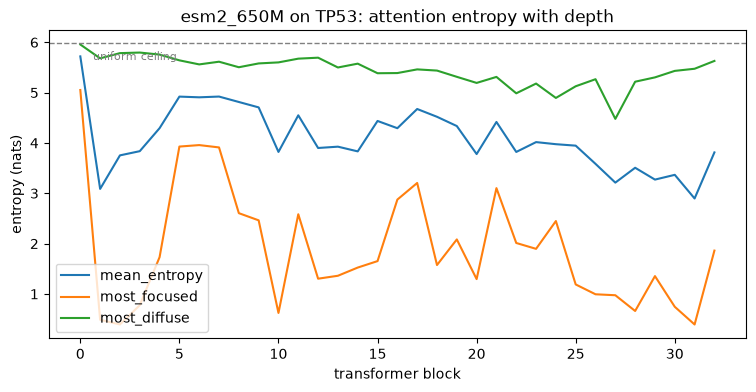

In [30]:
ax = depth[["mean_entropy", "most_focused", "most_diffuse"]].plot(
    figsize=(9, 4), title=f"{ATTN_MODEL} on {ATTN_PROTEIN}: attention entropy with depth")
ax.set_xlabel("transformer block")
ax.set_ylabel("entropy (nats)")
ax.axhline(np.log(tokens["input_ids"].shape[1]), ls="--", c="grey", lw=1)
ax.annotate("uniform ceiling", xy=(0.5, np.log(tokens["input_ids"].shape[1])),
            xytext=(2, -12), textcoords="offset points", fontsize=8, color="grey")

`head_uniformity` measures the same thing on a fixed 0–1 scale, which is what
lets you compare across models and sequence lengths rather than only across
blocks of one model.

### Which residues does the model read?

`received_attention` sums the attention each token *receives*. For a protein this
is directly checkable: TP53's domain boundaries are annotated in UniProt
(P04637), so we can ask whether the high-attention residues fall in the
structured DNA-binding core or in the disordered tails.

In [31]:
mass = tl.received_attention(attn[last])[0]      # (seq_len,)

# ESM prepends <cls>, so residue i (1-based) is token i.
top = np.argsort(mass)[::-1][:12]
print(f"{'token':>6}  {'residue':>9}  {'attention':>10}")
for t in top:
    aa = sequence[t - 1] if 1 <= t <= len(sequence) else "<special>"
    label = f"{aa}{t}" if aa != "<special>" else f"tok{t}"
    print(f"{t:>6}  {label:>9}  {mass[t]:>10.4f}")

 token    residue   attention
     0       tok0      0.0315
   394     tok394      0.0235
   277       C277      0.0135
   275       C275      0.0075
   242       C242      0.0073
   249       R249      0.0068
   176       C176      0.0044
   241       S241      0.0043
   134       F134      0.0042
   245       G245      0.0042
   248       R248      0.0041
     1         M1      0.0040


In [32]:
# UniProt P04637 domain architecture.
DOMAINS = {
    "transactivation (1-42, disordered)": (1, 42),
    "proline-rich (63-97)": (63, 97),
    "DNA-binding core (102-292)": (102, 292),
    "tetramerisation (323-356)": (323, 356),
    "C-terminal regulatory (363-393, disordered)": (363, 393),
}

rows = []
for name, (start, end) in DOMAINS.items():
    positions = [p for p in range(start, end + 1) if p <= len(sequence)]
    share = float(mass[positions].sum())
    rows.append({"domain": name, "residues": len(positions),
                 "attention_share": share,
                 "per_residue": share / max(len(positions), 1)})

domain_table = pd.DataFrame(rows).set_index("domain")
domain_table["vs_uniform"] = (domain_table["per_residue"]
                              / (1.0 / tokens["input_ids"].shape[1]))
display(domain_table.round(4))
print("\nvs_uniform > 1 means the domain draws more attention per residue than "
      "a flat distribution would give it.")

,residues,attention_share,per_residue,vs_uniform
domain,,,,
"transactivation (1-42, disordered)",42,0.0885,0.0021,0.8323
proline-rich (63-97),35,0.0641,0.0018,0.7236
DNA-binding core (102-292),191,0.5170,0.0027,1.0692
tetramerisation (323-356),34,0.0834,0.0025,0.9689
"C-terminal regulatory (363-393, disordered)",31,0.0624,0.0020,0.7957



vs_uniform > 1 means the domain draws more attention per residue than a flat distribution would give it.


In [33]:
# Is the top of that list a coincidence? p53's core binds a structural Zn(2+) ion
# through four ligands (C176, H179, C238, C242) and grips DNA through R248/R273,
# so the ranking can be checked against annotation instead of eyeballed.
ZINC_LIGANDS = {176, 179, 238, 242}
DNA_CONTACTS = {248, 273, 280, 283}
CORE = set(range(102, 293))

top_n = 12
ranked = [int(t) for t in np.argsort(mass)[::-1] if 1 <= t <= len(sequence)][:top_n]
residues = [(t, sequence[t - 1]) for t in ranked]

print("top attended residues: " + ", ".join(f"{aa}{pos}" for pos, aa in residues))
print(f"  in the DNA-binding core  : {sum(p in CORE for p, _ in residues)}/{top_n}"
      f"   (core is {len(CORE) / len(sequence):.0%} of the sequence)")
print(f"  cysteines                : {sum(aa == 'C' for _, aa in residues)}/{top_n}"
      f"   (Cys is {sequence.count('C') / len(sequence):.0%} of the sequence)")
print("  annotated Zn(2+) ligands : "
      + (", ".join(f"{aa}{p}" for p, aa in residues if p in ZINC_LIGANDS) or "none"))
print("  annotated DNA contacts   : "
      + (", ".join(f"{aa}{p}" for p, aa in residues if p in DNA_CONTACTS) or "none"))

top attended residues: C277, C275, C242, R249, C176, S241, F134, G245, R248, M1, W23, M243
  in the DNA-binding core  : 10/12   (core is 49% of the sequence)
  cysteines                : 4/12   (Cys is 3% of the sequence)
  annotated Zn(2+) ligands : C242, C176
  annotated DNA contacts   : R248


This is the payoff of looking inside the model. Nothing told ESM-2 where p53's zinc
site or DNA interface is — it saw sequences, never structures or annotations — yet
its attention concentrates on the cysteines of the DNA-binding core, including
ligands of the structural Zn²⁺ ion, and on the arginines that contact DNA. Those
are the residues whose mutation actually destroys p53 function in tumours.

Two honest qualifications. Cysteine is a rare residue, and rare tokens routinely
attract attention in language models for reasons unrelated to function, so some of
this may be a frequency effect rather than a structural one. And per the caveat at
the top, concentration is not causation. What this gives you is a structural
readout that lines up with known biology — a good reason to look further, not a
finished result.

`attention_to_gene_set` does this per head rather than pooled, so you can see
whether a *few specialised heads* carry a domain's signal or whether all of them
attend to it evenly. (The name is from the single-cell case, where tokens are
genes and the set is a pathway; here the set is a domain.)

In [34]:
core = [p for p in range(102, 293) if p <= len(sequence)]
tail = [p for p in range(363, 394) if p <= len(sequence)]

comparison = []
for layer in sorted(attn):
    core_heads = tl.attention_to_gene_set(attn[layer], core)
    tail_heads = tl.attention_to_gene_set(attn[layer], tail)
    comparison.append({
        "block": layer,
        "core_mean": float(core_heads.mean()),
        "core_max_head": float(core_heads.max()),
        "tail_mean": float(tail_heads.mean()),
        "tail_max_head": float(tail_heads.max()),
    })

domains_by_depth = pd.DataFrame(comparison).set_index("block")
display(domains_by_depth.round(3).iloc[::4])

print(f"\nDNA-binding core is {len(core)}/{len(sequence)} = "
      f"{len(core)/len(sequence):.0%} of the sequence, so a model attending "
      "uniformly would put that fraction of its mass there.")

,core_mean,core_max_head,tail_mean,tail_max_head
block,,,,
0,0.501,0.574,0.076,0.085
4,0.535,0.618,0.065,0.151
8,0.526,0.796,0.071,0.222
12,0.587,0.792,0.052,0.085
16,0.588,0.804,0.056,0.081
20,0.625,0.902,0.042,0.078
24,0.614,0.772,0.039,0.087
28,0.549,0.663,0.053,0.141
32,0.517,0.857,0.062,0.084



DNA-binding core is 191/393 = 49% of the sequence, so a model attending uniformly would put that fraction of its mass there.


### Attention summaries satisfy the output contract

The reductions are already `(n_entities, n_dims)`, so they store in `.obsm` and
inherit every exporter and the provenance record — no parallel result type.

In [35]:
attention_space = ad.AnnData(
    X=np.zeros((1, 1), dtype=np.float32),
    obs=pd.DataFrame({"protein": [ATTN_PROTEIN]}, index=[ATTN_PROTEIN]),
)
attention_space.obsm["X_attn_entropy"] = tl.attention_entropy(attn[last])
attention_space.obsm["X_attn_received"] = tl.received_attention(attn[last])
attention_space.obsm["X_attn_uniformity"] = tl.head_uniformity(attn[last])

print({key: value.shape for key, value in attention_space.obsm.items()})
del attn                      # a rank-4 tensor per block adds up; drop it early
embedder.clear_model_cache()

{'X_attn_entropy': (1, 20), 'X_attn_received': (1, 395), 'X_attn_uniformity': (1, 20)}


### What you cannot get, and why

Not every protein model can do this, and embpy says so instead of returning
something meaningless. ESM-C and ESM3 share an attention layer that calls
`F.scaled_dot_product_attention` unconditionally
(`esm/layers/attention.py:70,76`): the fused kernel computes the softmax inside
the kernel and returns only the output, so the per-head matrix never exists as a
tensor and no forward hook can recover it.

They therefore declare `has_attention = False` and fail fast with the reason,
rather than running a forward pass that cannot produce weights.

In [36]:
for key in ["esm2_650M", "esm1b", "prot_t5_xl_half", "esmc_300m", "esm3_small"]:
    try:
        w = embedder.get_model(key, load=False)      # no weights downloaded
        verdict = "extractable" if w.has_attention else "declared unavailable"
        print(f"  {key:18s} has_attention={str(w.has_attention):5s}  {verdict}")
    except Exception as exc:
        print(f"  {key:18s} unavailable here ({type(exc).__name__})")

  esm2_650M          has_attention=True   extractable
  esm1b              has_attention=True   extractable
  prot_t5_xl_half    has_attention=True   extractable
  esmc_300m          has_attention=False  declared unavailable
  esm3_small         has_attention=False  declared unavailable


In [37]:
# The failure is explanatory rather than a bare exception.
try:
    dummy = embedder.get_model("esmc_300m", load=False)
    dummy.extract_attention(np.zeros((1, 8), dtype="int64"), layers=[-1])
except NotImplementedError as exc:
    print(f"NotImplementedError: {exc}")
except Exception as exc:
    print(f"{type(exc).__name__}: {exc}")

NotImplementedError: ESMCWrapper wraps an architecture whose attention weights are not observable -- either it is attention-free (state-space, implicit convolution, graph message passing) or it computes attention with a fused kernel that never materialises the matrix. Use extract_hidden_states() for per-layer activations instead.


One implementation detail worth knowing, because it changes results silently:
recent `transformers` releases default these architectures to the **SDPA** kernel,
which also cannot return weights. embpy switches the model to eager attention for
the duration of the extraction forward pass and restores the original setting
afterwards, so `extract_attention` works on a default-loaded model and your
embedding calls keep the faster kernel.

The full per-model matrix — including the single-cell models — is in
[the attention-extraction reference](../attention_extraction.md).

## Downstream: which model predicts a measured property?

Structural comparison says the models differ; a benchmark says which difference
*pays*. `tl.benchmark_embeddings` trains probes on an embedding and scores them
against a target.

Three targets, chosen because they should behave *differently* — a benchmark you
cannot fail is not a benchmark:

| Target | What it is | Prior expectation |
| --- | --- | --- |
| `length` | residue count | **easy** — mean pooling is known to leak length |
| `prot_n_ptms` | curated modification sites | plausible — PTM motifs are sequence patterns |
| `prot_n_interactions` | curated interaction partners | **should fail** — hub-ness is a network property, not a sequence one |

R² is on the standard scale where 0 means "no better than predicting the mean" and
**negative values mean worse than that**. A model scoring below zero on
interaction count is the correct answer, not a broken run.

In [38]:
TARGETS = [t for t in ["length", "prot_n_ptms", "prot_n_interactions"]
           if t in protein_space.obs]

# benchmark_embeddings returns one row per regressor, indexed by regressor name.
benchmarks: dict[tuple[str, str], pd.DataFrame] = {}
for target in TARGETS:
    for key in keys:
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                benchmarks[(target, key)] = tl.benchmark_embeddings(
                    protein_space, perturbation_column="symbol",
                    perturbation_type="genetic", target=target,
                    obsm_key=spaces[key],
                    models=["linear", "ridge", "knn", "random_forest"],
                    mode="quick", test_size=0.25, random_state=0,
                )
        except Exception as exc:
            print(f"{target} / {key}: skipped -- {type(exc).__name__}: {str(exc)[:70]}")

best_r2 = pd.DataFrame(
    {target: {key: benchmarks[(target, key)]["r2"].max()
              for key in keys if (target, key) in benchmarks}
     for target in TARGETS}
)
print("best R2 over four probes (rows = model, columns = target)")
display(best_r2.round(3))

best R2 over four probes (rows = model, columns = target)


,length,prot_n_ptms,prot_n_interactions
esm1b,0.395,0.510,0.026
esm1v_1,0.461,0.487,-0.151
esm2_650M,0.403,0.649,-0.244
esmc_300m,0.355,0.480,0.096
prot_t5_xl_half,0.548,0.610,-0.252


In [39]:
# Spread across targets is the diagnostic: a target that every model fails tells
# you about the target, not about the models.
per_target = pd.DataFrame({
    "best_r2": best_r2.max(),
    "best_model": best_r2.idxmax(),
    "worst_r2": best_r2.min(),
})
display(per_target.round(3))

# A positive R2 is not automatically signal: with ten test points anything near
# zero is noise, so tier the verdict instead of reporting "beats the mean".
SIGNAL, NOISE = 0.30, 0.10
for target, row in per_target.iterrows():
    r2, model = row["best_r2"], row["best_model"]
    if r2 >= SIGNAL:
        verdict = f"real signal (R2={r2:.3f}, {model})"
    elif r2 >= NOISE:
        verdict = f"at the noise floor (R2={r2:.3f}) -- not a usable predictor"
    else:
        verdict = f"nothing usable (best R2={r2:.3f}); most models do worse than the mean"
    print(f"  {target:22s} {verdict}")

,best_r2,best_model,worst_r2
length,0.548,prot_t5_xl_half,0.355
prot_n_ptms,0.649,esm2_650M,0.480
prot_n_interactions,0.096,esmc_300m,-0.252


  length                 real signal (R2=0.548, prot_t5_xl_half)
  prot_n_ptms            real signal (R2=0.649, esm2_650M)
  prot_n_interactions    nothing usable (best R2=0.096); most models do worse than the mean


all four probes for esm2_650M predicting prot_n_ptms:


,mse,r2,pearson,spearman,delta_l2_mae,delta_l2_pearson
model,,,,,,
linear,75.905,0.362,0.770,0.869,NaN,NaN
ridge,41.740,0.649,0.820,0.869,NaN,NaN
knn,95.748,0.195,0.469,0.474,NaN,NaN
random_forest,60.669,0.490,0.755,0.547,NaN,NaN


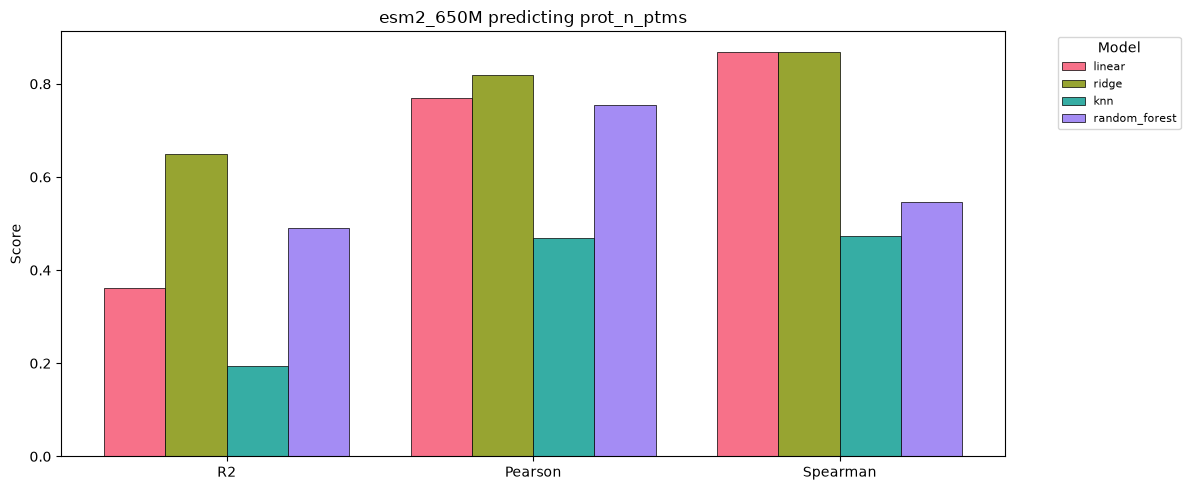

In [40]:
# Full per-probe detail for the best (target, model) pair, plus the standard plot.
if benchmarks:
    top_target = per_target["best_r2"].idxmax()
    top_model = per_target.loc[top_target, "best_model"]
    print(f"all four probes for {top_model} predicting {top_target}:")
    display(benchmarks[(top_target, top_model)].round(3))
    pl.plot_benchmark(benchmarks[(top_target, top_model)],
                      title=f"{top_model} predicting {top_target}")

**Read the baseline, not the winner.** `benchmark_embeddings` trains a plain
linear probe alongside the rest; a foundation model that cannot beat linear-on-its
own-embedding bought you nothing for this task.

**And treat these particular numbers as a demonstration, not a result.** Forty
proteins with a single 25% split is ten test points — far too few for a stable
R², so the ranking between close models here should not be trusted. For a real
decision use `mode="rigorous"` (5-fold CV with hyper-parameter search) and hold
out whole functional classes rather than random rows, so the score reflects
generalisation instead of memorising which protein is which.

That `length` is the easiest target is itself worth pausing on: it confirms
mean-pooled embeddings encode how long the sequence was. If your real target
correlates with protein length, a probe can score well by reading off length and
learning nothing about your biology — so regress length out, or stratify by it.

`tl.__all__` also carries `phenotypic_activity`, the perturbation-screen
readouts (`delta_l2`, `deg_overlap`, `phenocopy_score`), and
`compute_scib_metrics`. Those want perturbation or single-cell data — an
`.obs` control column, or batch and cell-type labels — which a panel of 40
protein sequences does not have, so they belong in
[cells](cells.ipynb) rather than here.

## Protein-only: does embedding distance track evolutionary distance?

Everything so far applies to any modality. The next two sections do not: they
need orthology and residue positions, so they exist only for proteins.

`build_cross_species_adata` resolves orthologs through Ensembl Compara, fetches
each species' protein sequence, and embeds them into one AnnData with
`sequence_identity` recorded per protein. `identity_vs_similarity` then pairs
sequence identity against embedding similarity for every ortholog pair.

Ensembl's REST API is rate-limited and intermittently times out, so this is
wrapped: a partial table is still informative, and a failed lookup drops one
gene rather than the section.

In [41]:
CROSS_SPECIES_GENES = ["TP53", "CDK1", "MAPK1", "GAPDH", "CASP3", "SRC", "JUN", "LDHA"]
SPECIES = ["human", "mouse", "zebrafish"]

cross_species = None
try:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        cross_species = tl.build_cross_species_adata(
            embedder, genes=CROSS_SPECIES_GENES, species=SPECIES,
            model="esm2_8M", source_species="human",
        )
    print(f"resolved {cross_species.n_obs} proteins "
          f"across {cross_species.obs['species_short'].nunique()} species")
    display(cross_species.obs.groupby("species_short", observed=True)
            .agg(n=("symbol", "size"), mean_identity=("sequence_identity", "mean")).round(1))
except Exception as exc:
    print(f"cross-species build unavailable: {type(exc).__name__}: {str(exc)[:160]}")
finally:
    embedder.clear_model_cache()

resolved 20 proteins across 3 species


,n,mean_identity
species_short,,
Danio,6,82.4
Homo,8,100.0
Mus,6,95.2


In [42]:
identity_table = None
if cross_species is not None and cross_species.n_obs > 2:
    identity_table = tl.identity_vs_similarity(cross_species, obsm_key="X_emb")
    display(identity_table.round(3))

    if len(identity_table) > 2:
        rho = identity_table[["sequence_identity", "embedding_similarity"]].corr(
            method="spearman").iloc[0, 1]
        print(f"\nSpearman(sequence identity, embedding similarity) = {rho:.3f} "
              f"over {len(identity_table)} ortholog pairs")

,gene_family,species_a,species_b,symbol_a,symbol_b,sequence_identity,embedding_similarity
0,CDK1,Homo,Mus,CDK1,Cdk1,96.970,0.999
1,CDK1,Homo,Danio,CDK1,cdk1,83.502,0.995
2,CDK1,Mus,Danio,Cdk1,cdk1,83.502,0.995
3,MAPK1,Homo,Mus,MAPK1,Mapk1,98.611,1.000
4,MAPK1,Homo,Danio,MAPK1,mapk1,92.778,0.998
5,MAPK1,Mus,Danio,Mapk1,mapk1,92.778,0.997
6,GAPDH,Homo,Danio,GAPDH,gapdh,85.672,0.995
7,CASP3,Homo,Mus,CASP3,Casp3,86.643,0.997
8,SRC,Homo,Mus,SRC,Src,98.694,1.000
9,SRC,Homo,Danio,SRC,src,83.396,0.991



Spearman(sequence identity, embedding similarity) = 0.970 over 17 ortholog pairs


In [43]:
if cross_species is not None and cross_species.n_obs > 2:
    display(tl.ortholog_similarity_matrix(cross_species, obsm_key="X_emb").round(3))

,TP53_Homo,CDK1_Homo,Cdk1_Mus,cdk1_Danio,MAPK1_Homo,Mapk1_Mus,mapk1_Danio,GAPDH_Homo,gapdh_Danio,CASP3_Homo,Casp3_Mus,SRC_Homo,Src_Mus,src_Danio,JUN_Homo,Jun_Mus,jun_Danio,LDHA_Homo,ENSMUSG00000063229_Mus,ENSDARG00000101251_Danio
TP53_Homo,1.000,0.697,0.704,0.689,0.805,0.801,0.826,0.912,0.907,0.878,0.886,0.897,0.897,0.890,0.936,0.935,0.935,0.921,0.925,0.923
CDK1_Homo,0.697,1.000,0.999,0.995,0.968,0.969,0.961,0.693,0.677,0.774,0.766,0.895,0.897,0.901,0.686,0.686,0.697,0.711,0.712,0.711
Cdk1_Mus,0.704,0.999,1.000,0.995,0.966,0.967,0.960,0.699,0.684,0.778,0.769,0.898,0.900,0.903,0.691,0.690,0.701,0.718,0.720,0.719
cdk1_Danio,0.689,0.995,0.995,1.000,0.965,0.965,0.958,0.683,0.669,0.765,0.756,0.890,0.892,0.893,0.677,0.676,0.686,0.698,0.701,0.705
MAPK1_Homo,0.805,0.968,0.966,0.965,1.000,1.000,0.998,0.784,0.772,0.842,0.836,0.935,0.937,0.943,0.789,0.790,0.801,0.793,0.796,0.793
Mapk1_Mus,0.801,0.969,0.967,0.965,1.000,1.000,0.997,0.779,0.767,0.840,0.835,0.932,0.934,0.940,0.785,0.786,0.798,0.790,0.792,0.789
mapk1_Danio,0.826,0.961,0.960,0.958,0.998,0.997,1.000,0.801,0.791,0.849,0.844,0.945,0.947,0.953,0.809,0.809,0.818,0.807,0.810,0.808
GAPDH_Homo,0.912,0.693,0.699,0.683,0.784,0.779,0.801,1.000,0.995,0.868,0.876,0.843,0.843,0.840,0.867,0.865,0.871,0.980,0.981,0.981
gapdh_Danio,0.907,0.677,0.684,0.669,0.772,0.767,0.791,0.995,1.000,0.857,0.864,0.839,0.838,0.835,0.861,0.860,0.863,0.975,0.976,0.976
CASP3_Homo,0.878,0.774,0.778,0.765,0.842,0.840,0.849,0.868,0.857,1.000,0.997,0.867,0.870,0.875,0.827,0.826,0.846,0.893,0.890,0.881


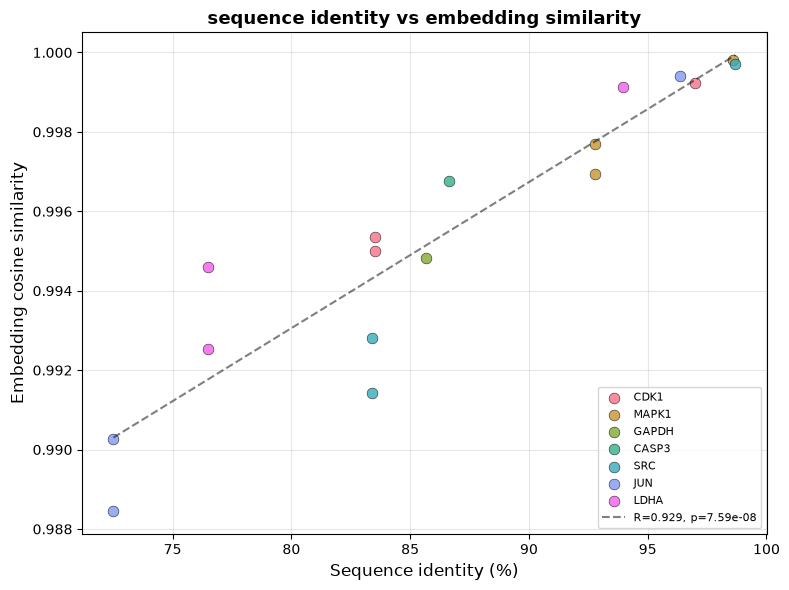

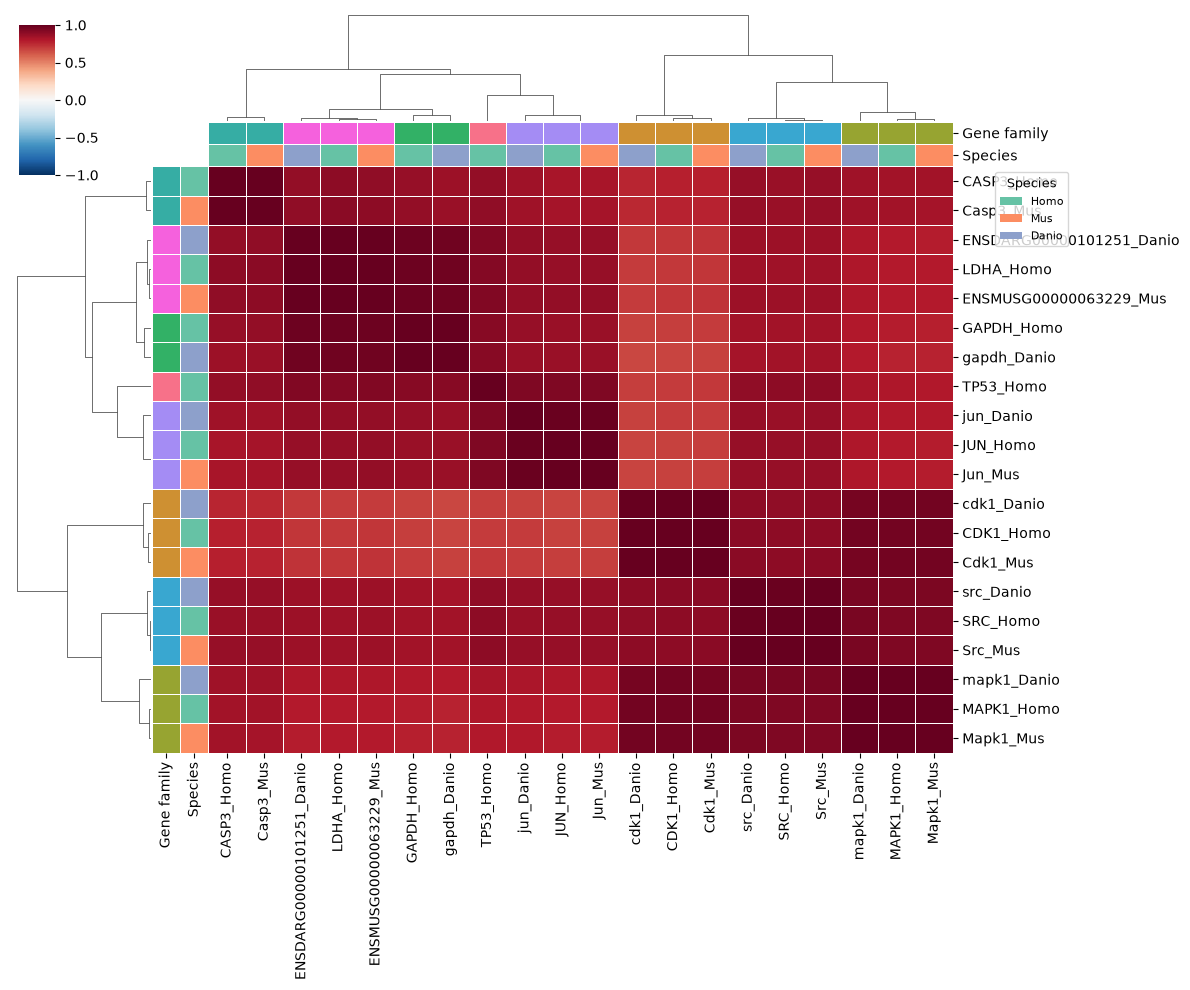

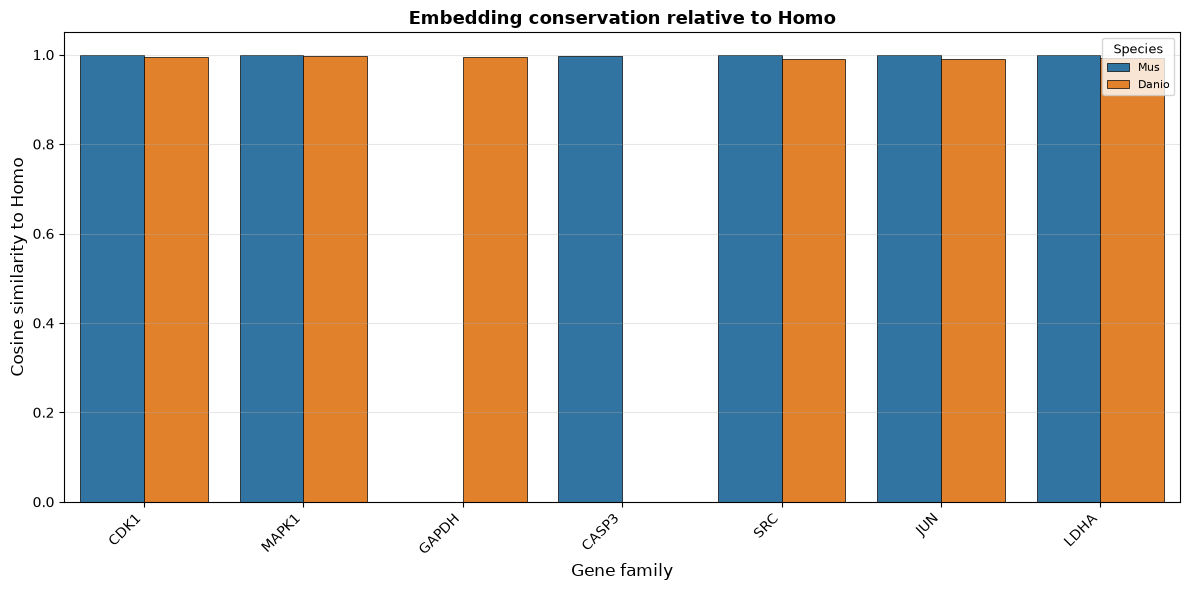

In [44]:
# The four protein/cross-species plots in embpy.pl.
if identity_table is not None and len(identity_table):
    pl.plot_identity_vs_similarity(identity_table,
                                   title="sequence identity vs embedding similarity")
if cross_species is not None and cross_species.n_obs > 2:
    pl.plot_ortholog_similarity(cross_species, obsm_key="X_emb")
    pl.plot_conservation_barplot(cross_species, obsm_key="X_emb",
                                 reference_species="Homo")

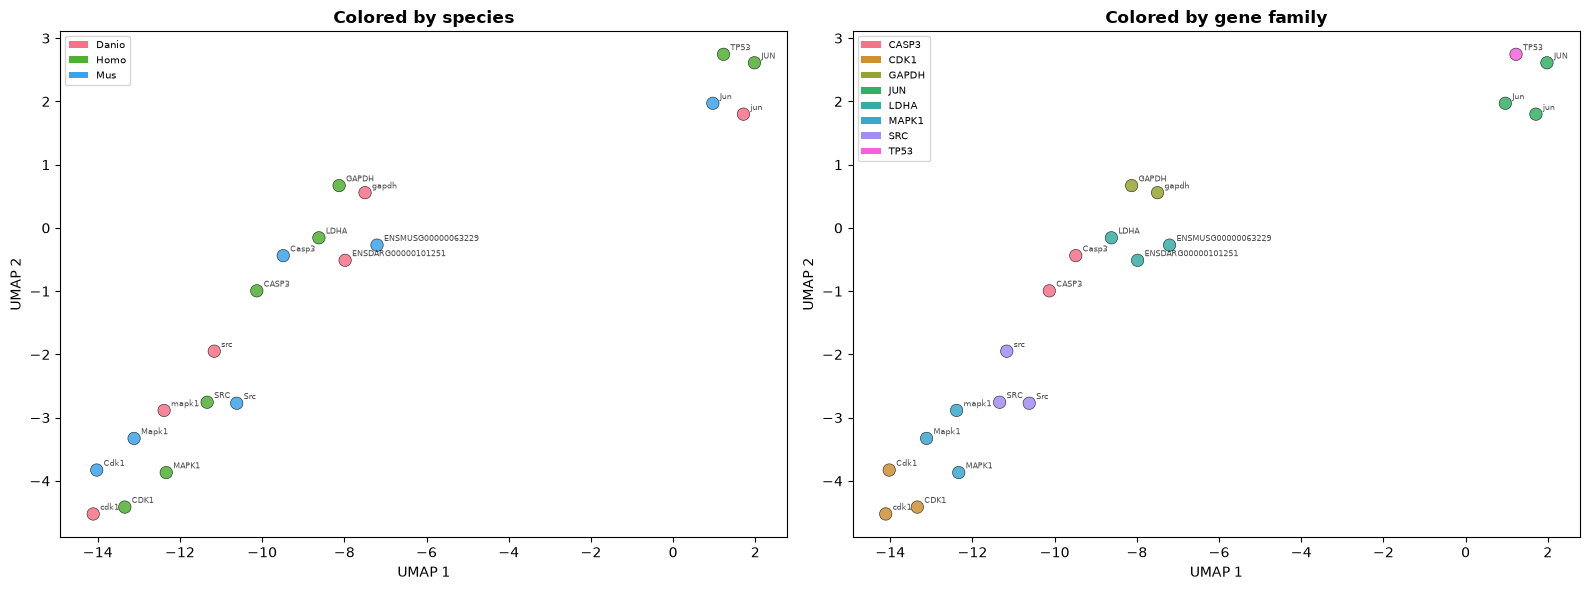

In [45]:
# plot_species_umap needs enough rows for a spectral UMAP initialisation.
if cross_species is not None and cross_species.n_obs >= 15:
    pl.plot_species_umap(cross_species, obsm_key="X_emb")
elif cross_species is not None:
    print(f"only {cross_species.n_obs} proteins resolved -- UMAP needs ~15+ rows "
          "for a spectral initialisation, so this plot is skipped.")

## Protein-only: how far does a point mutation move the embedding?

`id_type="sequence"` embeds a raw amino-acid string, so you can compare a wild
type against a variant you construct yourself. TP53's hotspot mutations are among
the best-characterised in cancer genetics, which makes them a fair test — and the
result is a useful negative one.

Note that `embed()`'s AnnData path deliberately accepts only resolvable
identifiers (`symbol`, `ensembl_id`, `uniprot_id`); raw sequences go through
`embed_protein`.

In [46]:
# Position/residue pairs are asserted against the resolved sequence rather than
# trusted, so a UniProt isoform change would fail loudly instead of silently
# mutating the wrong residue.
VARIANTS = [("R175H", 175, "R", "H", "hotspot, structural DNA-binding"),
            ("R248Q", 248, "R", "Q", "hotspot, DNA contact"),
            ("R273H", 273, "R", "H", "hotspot, DNA contact"),
            ("R282W", 282, "R", "W", "hotspot, structural"),
            ("P72R",   72, "P", "R", "common benign polymorphism")]

wt = sequences["TP53"]
wrapper = embedder.get_model("esm2_650M")

wt_vector = np.asarray(wrapper.embed(wt, pooling_strategy="mean"))
rows = []
for name, position, expected, replacement, note in VARIANTS:
    observed = wt[position - 1]
    if observed != expected:
        print(f"{name}: expected {expected}{position}, found {observed}{position} -- skipped")
        continue
    mutant = wt[:position - 1] + replacement + wt[position:]
    vector = np.asarray(wrapper.embed(mutant, pooling_strategy="mean"))
    cosine = float(vector @ wt_vector /
                   (np.linalg.norm(vector) * np.linalg.norm(wt_vector)))
    rows.append({"variant": name, "cosine_to_wt": cosine,
                 "l2_shift": float(np.linalg.norm(vector - wt_vector)),
                 "note": note})

variant_table = pd.DataFrame(rows).set_index("variant")
display(variant_table.round(6))

,cosine_to_wt,l2_shift,note
variant,,,
R175H,0.999970,0.067344,"hotspot, structural DNA-binding"
R248Q,0.999951,0.084145,"hotspot, DNA contact"
R273H,0.999983,0.050457,"hotspot, DNA contact"
R282W,0.999985,0.045370,"hotspot, structural"
P72R,0.999976,0.056631,common benign polymorphism


In [47]:
# How big is that shift compared with the distances the panel actually spans?
panel_matrix = embeddings["esm2_650M"] if "esm2_650M" in embeddings else None
if panel_matrix is not None and len(variant_table):
    from scipy.spatial.distance import pdist
    between_proteins = pdist(panel_matrix, metric="euclidean")
    biggest_variant = variant_table["l2_shift"].max()
    print(f"largest single-residue shift : {biggest_variant:.4f}")
    print(f"closest two distinct proteins: {between_proteins.min():.4f}")
    print(f"median protein-protein L2    : {np.median(between_proteins):.4f}")
    print(f"\nratio (variant shift / median protein distance): "
          f"{biggest_variant / np.median(between_proteins):.4f}")

largest single-residue shift : 0.0841
closest two distinct proteins: 0.6285
median protein-protein L2    : 3.5329

ratio (variant shift / median protein distance): 0.0238


The shift from a hotspot mutation is orders of magnitude smaller than the
distance between two different proteins — one substitution in ~400 residues
barely moves a **mean-pooled** vector, because pooling averages the change away.
That is a property of the pooling, not evidence that the model is blind to the
mutation: the per-residue representation at that position does change.

So for variant effect prediction, do not diff mean-pooled embeddings. Use the
per-residue output (`pooling_strategy="none"`), or a model trained for the task —
`esm1v_*` exists precisely for this, and ships as a 5-seed ensemble because a
single seed is noisy. embpy's variant-effect tooling
([variant_effects.ipynb](variant_effects.ipynb)) works on DNA rather than
protein sequence.

## Protein-only: one gene, several proteins

Point mutations are one axis of sequence variation; **isoforms** are the other,
and a much larger one. Alternative splicing means a single gene yields several
distinct proteins, and UniProt curates them. `embed_protein(..., isoform="all")`
returns one vector per isoform instead of collapsing the gene to its canonical
sequence.

TP53 is a good demonstration: UniProt records nine isoforms for it, several
truncated at the N- or C-terminus, and some (Δ133p53, p53β/γ) have their own
documented biology.

In [48]:
isoform_vectors = embedder.embed_protein(
    "TP53", model="esm2_650M", id_type="symbol", isoform="all",
)
isoform_sequences = resolver.get_isoforms("TP53", id_type="symbol")

canonical_id = min(isoform_vectors, key=len)      # the displayed sequence has no -N suffix
canonical_vec = np.asarray(isoform_vectors[canonical_id])

rows = []
for accession, vector in sorted(isoform_vectors.items()):
    vector = np.asarray(vector)
    rows.append({
        "accession": accession,
        "residues": len(isoform_sequences.get(accession, "")),
        "cosine_to_canonical": float(
            vector @ canonical_vec
            / (np.linalg.norm(vector) * np.linalg.norm(canonical_vec))
        ),
    })

isoform_table = pd.DataFrame(rows).set_index("accession")
isoform_table["is_canonical"] = isoform_table.index == canonical_id
display(isoform_table.round(4))

print(f"\n{len(isoform_vectors)} isoforms embedded; "
      f"canonical is {canonical_id} at {isoform_table.loc[canonical_id, 'residues']} residues")

,residues,cosine_to_canonical,is_canonical
accession,,,
P04637,393,1.0000,True
P04637-2,341,0.9989,False
P04637-3,346,0.9988,False
P04637-4,354,0.9992,False
P04637-5,302,0.9974,False
P04637-6,307,0.9974,False
P04637-7,261,0.9936,False
P04637-8,209,0.9867,False
P04637-9,214,0.9870,False



9 isoforms embedded; canonical is P04637 at 393 residues


In [49]:
# Compare the spread of isoform-vs-canonical distances against the point
# mutations above -- same gene, same model, two kinds of sequence change.
iso_shift = 1 - isoform_table.loc[~isoform_table["is_canonical"], "cosine_to_canonical"]
if len(variant_table):
    var_shift = 1 - variant_table["cosine_to_wt"]
    print(f"{'':22s}{'median':>12}{'max':>12}")
    print(f"{'single-residue variant':22s}{var_shift.median():>12.6f}{var_shift.max():>12.6f}")
    print(f"{'isoform':22s}{iso_shift.median():>12.6f}{iso_shift.max():>12.6f}")
    print(f"\nisoform / variant ratio (median): "
          f"{iso_shift.median() / max(var_shift.median(), 1e-12):.0f}x")

                            median         max
single-residue variant    0.000024    0.000049
isoform                   0.002610    0.013283

isoform / variant ratio (median): 111x


Isoforms move the embedding one to two orders of magnitude further than a point
mutation does, and the shift tracks how much sequence the isoform loses — the
shortest isoforms sit furthest from the canonical vector. That is the same
mean-pooling behaviour seen in the length benchmark above, now working in your
favour: pooling is insensitive to single substitutions but very sensitive to
losing a domain.

The practical consequence is that **which isoform you embed is a real modelling
decision**, not an implementation detail. Defaulting to canonical is defensible
and is what `embed()` does, but if your assay measures a specific transcript,
embed that isoform instead.

> A caveat on counting: `prot_n_isoforms` from `annotate_proteins` counts the
> isoforms UniProt *describes*, while `isoform="all"` returns those it serves a
> distinct sequence for. The two agree for TP53 but need not in general.

## Protein-only: weighting residues before pooling

If mean pooling dilutes the residues you care about, weight them.
`tl.WeightedProteinEmbedder` pools with per-residue weights drawn from
annotation — boosting UniProt's active sites, binding sites and motifs — so
functional positions count more than the average residue.

In [50]:
weighted = tl.WeightedProteinEmbedder(embedder, organism="human")

rows = []
for gene in ["TP53", "CDK1", "SRC", "CASP3"]:
    try:
        plain = np.asarray(embedder.embed_protein(gene, model="esm2_650M", id_type="symbol"))
        boosted = np.asarray(weighted.annotation_weighted_embedding(
            gene, model="esm2_650M", site_boost=3.0))
        rows.append({"protein": gene,
                     "cosine_plain_vs_weighted": float(
                         boosted @ plain / (np.linalg.norm(boosted) * np.linalg.norm(plain))),
                     "l2_shift": float(np.linalg.norm(boosted - plain))})
    except Exception as exc:
        print(f"{gene}: {type(exc).__name__}: {str(exc)[:80]}")

if rows:
    display(pd.DataFrame(rows).set_index("protein").round(5))
    print("\nsite_boost=3.0 gives annotated functional residues 3x the weight of "
          "an average residue. Larger boosts move the vector further; whether "
          "that helps is a question for benchmark_embeddings on your task.")
embedder.clear_model_cache()

,cosine_plain_vs_weighted,l2_shift
protein,,
TP53,0.99947,0.30616
CDK1,0.99865,0.31497
SRC,0.99946,0.20631
CASP3,0.99972,0.12087



site_boost=3.0 gives annotated functional residues 3x the weight of an average residue. Larger boosts move the vector further; whether that helps is a question for benchmark_embeddings on your task.


`embed_perturbation` exposes the other weighting strategies from the same class
(`tpm_weighted`, `expression_context`, `annotation_weighted`, `full`) for when a
protein's embedding should reflect the expression context it acts in.

## Save the artifact

In [51]:
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# h5ad needs every .uns leaf to be a writable type. The UniProt records are
# deeply nested dicts, so serialise them; anything else that resists writing is
# serialised the same way rather than silently dropped.
to_write = protein_space.copy()
if "protein_annotations" in to_write.uns:
    to_write.uns["protein_annotations"] = json.dumps(
        {key: str(value) for key, value in to_write.uns["protein_annotations"].items()}
    )

path = OUTPUT_DIR / "protein_embeddings.h5ad"
try:
    to_write.write_h5ad(path)
except (TypeError, ValueError) as exc:
    print(f"first write attempt failed ({type(exc).__name__}), serialising .uns: {str(exc)[:100]}")
    to_write.uns = {key: json.dumps(str(value)) for key, value in to_write.uns.items()}
    to_write.write_h5ad(path)

print(f"wrote {path} ({path.stat().st_size / 1e6:.1f} MB)")
print(f"  obsm: {list(to_write.obsm)}")
print(f"  obs : {list(to_write.obs.columns)}")

# Round-trip it, because an artifact you cannot read back is not an artifact.
reloaded = ad.read_h5ad(path)
assert reloaded.n_obs == protein_space.n_obs
assert set(reloaded.obsm) == set(to_write.obsm)
print(f"  round-trip OK: {reloaded.n_obs} proteins, {len(reloaded.obsm)} embedding spaces")

wrote outputs/protein_embeddings.h5ad (2.1 MB)
  obsm: ['X_esm1b', 'X_esm1v_1', 'X_esm2_650M', 'X_esmc_300m', 'X_prot_t5_xl_half', 'X_pca_X_esm1b', 'X_pca_X_esm1v_1', 'X_pca_X_esm2_650M', 'X_pca_X_esmc_300m', 'X_pca_X_prot_t5_xl_half']
  obs : ['symbol', 'family', 'length', 'gene_symbol', 'knn_jaccard_X_esm1b_X_esm1v_1', 'knn_jaccard_X_esm1b_X_esm2_650M', 'knn_jaccard_X_esm1b_X_esmc_300m', 'knn_jaccard_X_esm1b_X_prot_t5_xl_half', 'knn_jaccard_X_esm1v_1_X_esm2_650M', 'knn_jaccard_X_esm1v_1_X_esmc_300m', 'knn_jaccard_X_esm1v_1_X_prot_t5_xl_half', 'knn_jaccard_X_esm2_650M_X_esmc_300m', 'knn_jaccard_X_esm2_650M_X_prot_t5_xl_half', 'knn_jaccard_X_esmc_300m_X_prot_t5_xl_half', 'cluster', 'prot_reviewed', 'prot_name', 'prot_n_domains', 'prot_n_ptms', 'prot_n_diseases', 'prot_n_interactions', 'prot_n_isoforms', 'prot_location']


  round-trip OK: 40 proteins, 10 embedding spaces


## Takeaway

**What ran here.** Five distinct protein models — ESM-1b, ESM-1v, ESM-2, ESM-C,
ProtT5 — over 40 proteins in five functional classes, compared with the global
metrics (`tsi`, `qsi`, `cka`, `similarity_correlation`), the local ones
(`compute_knn_overlap`, `knn_jaccard`, `mutual_knn`, `compare_embedding_matrices`),
and scored against labels no model ever saw.

**What to carry away.**

1. **Pick a model with a label, not a leaderboard.** The metric tables say the
   models differ; only `within_vs_between_similarity`, `knn_label_purity` and
   `benchmark_embeddings` — all scored against external labels — say which
   difference is worth anything for your task.
2. **The last layer is a choice, not a default.** `rank_layers` plus a
   class-separation sweep shows where the signal actually peaks.
3. **Mean pooling is lossy in a specific way.** It dilutes single-residue changes
   almost to nothing. Use per-residue output, a purpose-trained model, or
   `WeightedProteinEmbedder` when positions matter.
4. **Attention is available where the architecture materialises it** — ESM-2 and
   ProtT5 yes, ESM-C and ESM3 no, for a reason embpy can state. Read it as
   structural evidence, never as importance.

**Protein-specific tooling used here:** `identity_vs_similarity`,
`ortholog_similarity_matrix`, `build_cross_species_adata`,
`WeightedProteinEmbedder`, `annotate_proteins`, and the four `pl.plot_*` helpers
for cross-species comparison.

**Next.** [genes](genes.ipynb), [cells](cells.ipynb) and
[small molecules](small_molecules.ipynb) run the same programme for their
modalities. [Comparing embeddings](03_compare_embeddings.ipynb) is the reference
for choosing between the metrics used above.